In [1]:
import os
import sys
import sklearn
import keras_tuner
import numpy as np
import collections
import seaborn as sns
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from baseline import ResnetTuner
import train_constants as c

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("Modules"))))
import Modules.ds_loader as ds_loader

dataset_loader = ds_loader.DatasetLoader(
    xlsx_path="../Data/Internal_Dataset/Label_Map.xlsx",
    data_dir="../Data/Internal_Dataset",
)

X, y = dataset_loader.load_data()

X_train, X_temp, y_train, y_temp = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True
)
print(f"Class distribution of training: {collections.Counter(y_train)}")
print(f"Class distribution of validation: {collections.Counter(y_val)}")
print(f"Class distribution of test: {collections.Counter(y_test)}")
def min_max_normalize(*datasets):
    normalized_datasets = []
    for data in datasets:
        norm_data = []
        for sample in data:
            min_val = np.min(sample)
            max_val = np.max(sample)
            if max_val - min_val == 0:
                norm_sample = np.zeros_like(sample, dtype=np.float32)
            else:
                norm_sample = (sample - min_val) / (max_val - min_val)
            norm_data.append(norm_sample)
        normalized_datasets.append(np.stack(norm_data, axis=0).astype(np.float32))
    return normalized_datasets

2025-05-28 23:22:31.937273: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 23:22:31.948591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748467351.960016 1120041 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748467351.963772 1120041 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748467351.974598 1120041 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Class distribution of training: Counter({np.int32(2): 3136, np.int32(1): 1803, np.int32(0): 1773, np.int32(3): 1758})
Class distribution of validation: Counter({np.int32(2): 563, np.int32(3): 350, np.int32(1): 342, np.int32(0): 333})
Class distribution of test: Counter({np.int32(2): 189, np.int32(1): 115, np.int32(3): 114, np.int32(0): 112})


In [2]:
tuner = keras_tuner.RandomSearch(
    ResnetTuner(),
    objective="val_loss",
    max_trials=100,
    overwrite=False,
    directory=c.RDIR,
    project_name=f"RES_{c.INPUT_SIZE}_{c.FILTERS}",
)

tuner.reload()

best_trials = tuner.oracle.get_best_trials(num_trials=10)

for trial in best_trials:
    print(f"Trial ID: {trial.trial_id}, Score: {trial.score}")
    print("Hyperparameters:", trial.hyperparameters.values)

Reloading Tuner from Results/RES_500_64_09/RES_500_64/tuner0.json
Trial ID: 119, Score: 0.10949298739433289
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_units_1': 64, 'dropout_1': 0.3, 'dense_units_2': 64, 'dropout_2': 0.3, 'learning_rate': 0.005100109355686097, 'weight_decay': 0.004574004727815324, 'batch_size': 32}
Trial ID: 163, Score: 0.11351891607046127
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_units_1': 64, 'dropout_1': 0.35, 'dense_units_2': 64, 'dropout_2': 0.5, 'learning_rate': 0.0033870182724147825, 'weight_decay': 0.009308089454387202, 'batch_size': 32}
Trial ID: 124, Score: 0.1150164008140564
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_u

In [3]:
print(c.RDIR / f"RES_{c.INPUT_SIZE}_{c.FILTERS}" / "RESULTS.pkl")


Results/RES_500_64_09/RES_500_64/RESULTS.pkl


Loading individual model results...


I0000 00:00:1748467362.416043 1120041 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1172 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


✅ Loaded Model 1 results from Results/RES_500_64_09/RES_500_64/model_1.pkl
✅ Loaded Model 2 results from Results/RES_500_64_09/RES_500_64/model_2.pkl
✅ Loaded Model 3 results from Results/RES_500_64_09/RES_500_64/model_3.pkl
✅ Loaded Model 4 results from Results/RES_500_64_09/RES_500_64/model_4.pkl
✅ Loaded Model 5 results from Results/RES_500_64_09/RES_500_64/model_5.pkl
✅ Loaded Model 6 results from Results/RES_500_64_09/RES_500_64/model_6.pkl
✅ Loaded Model 7 results from Results/RES_500_64_09/RES_500_64/model_7.pkl
✅ Loaded Model 8 results from Results/RES_500_64_09/RES_500_64/model_8.pkl
✅ Loaded Model 9 results from Results/RES_500_64_09/RES_500_64/model_9.pkl
✅ Loaded Model 10 results from Results/RES_500_64_09/RES_500_64/model_10.pkl
✅ Loaded Model 11 results from Results/RES_500_64_09/RES_500_64/model_11.pkl
✅ Loaded Model 12 results from Results/RES_500_64_09/RES_500_64/model_12.pkl
✅ Loaded Model 13 results from Results/RES_500_64_09/RES_500_64/model_13.pkl
✅ Loaded Model 14

I0000 00:00:1748467382.152264 1285249 service.cc:152] XLA service 0x7f00f0001ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748467382.152288 1285249 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-05-28 23:23:02.166381: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748467382.270962 1285249 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1748467383.412473 1285249 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test - Model 1 Loss: 0.1333
Test - Model 1 Accuracy: 0.9604

Classification Report (Test - Model 1 Data):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       112
           1       0.94      0.90      0.92       115
           2       0.98      0.99      0.99       189
           3       0.98      0.96      0.97       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96      0.96       530

Test - Model 1 AUC: 0.9944


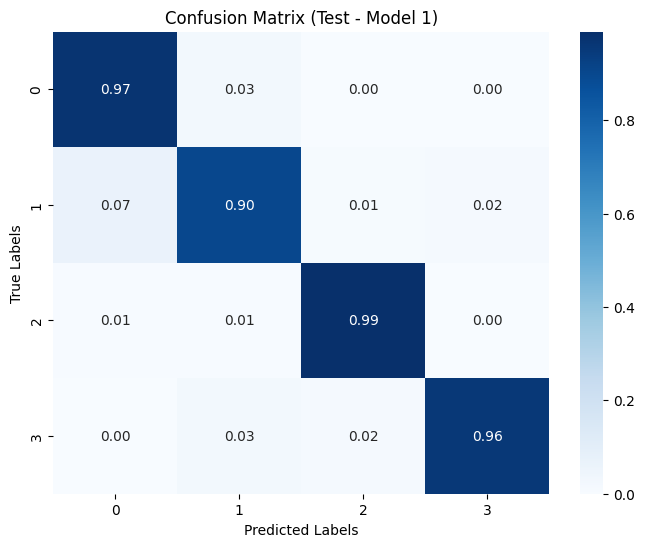


[== Evaluation on External - Model 1 Data ==]
External - Model 1 Loss: 0.9296
External - Model 1 Accuracy: 0.7961

Classification Report (External - Model 1 Data):
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1008
           1       0.25      0.99      0.40       229
           2       0.26      0.97      0.41       456
           3       0.99      0.78      0.88      9141

    accuracy                           0.80     10834
   macro avg       0.57      0.88      0.62     10834
weighted avg       0.93      0.80      0.84     10834

External - Model 1 AUC: 0.9664


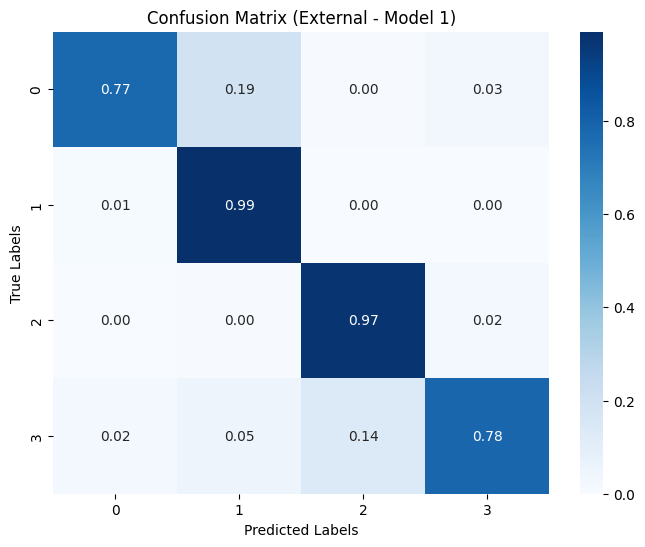

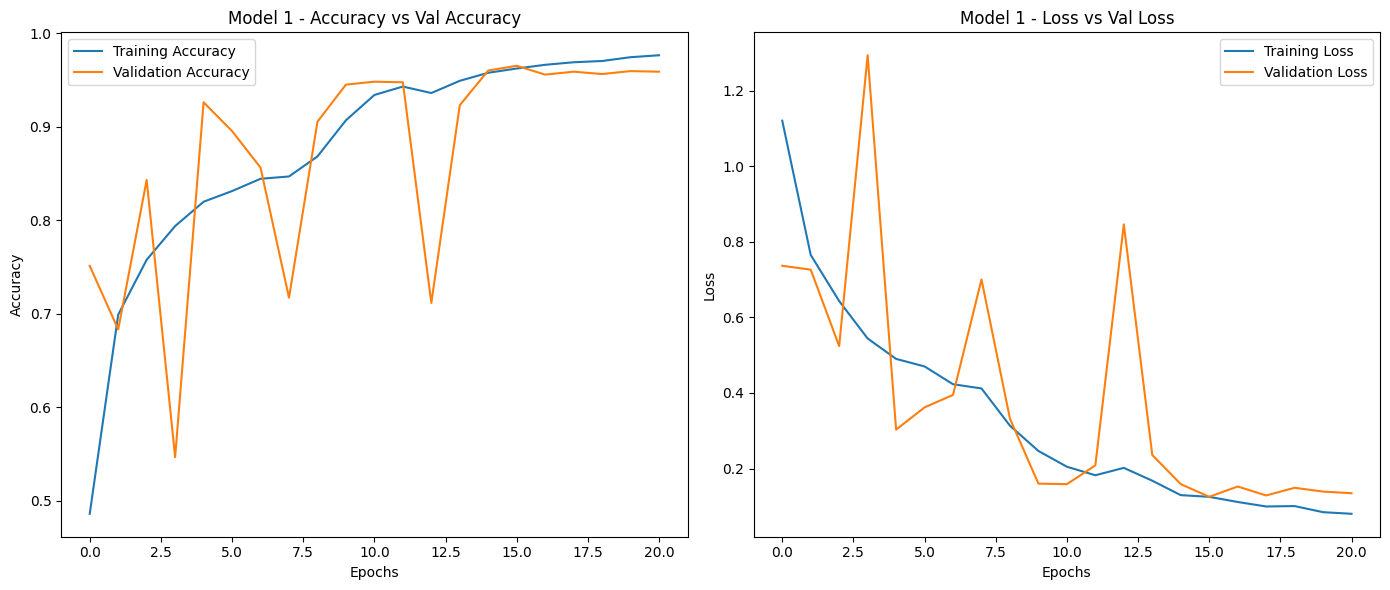


Model 1 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 2/30

Model 2 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.5
  learning_rate: 0.0033870182724147825
  weight_decay: 0.009308089454387202
  batch_size: 32

=== Evaluating Model 2 ===

[== Evaluation on Test - Model 2 Data ==]
Test - Model 2 Loss: 0.1835
Test - Model 2 Accuracy: 0.9434

Classification Report (Test - Model 2 Data):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       112
           1       0.91      0.90      0.90       115
           2       0.95      1.00      0.98       189
           3       0.99      0.91      0.95       114

    accuracy                           0.94       530
   macro avg       0.94      0.93      0.94       530
weighted avg       0.94      0.94      0.94

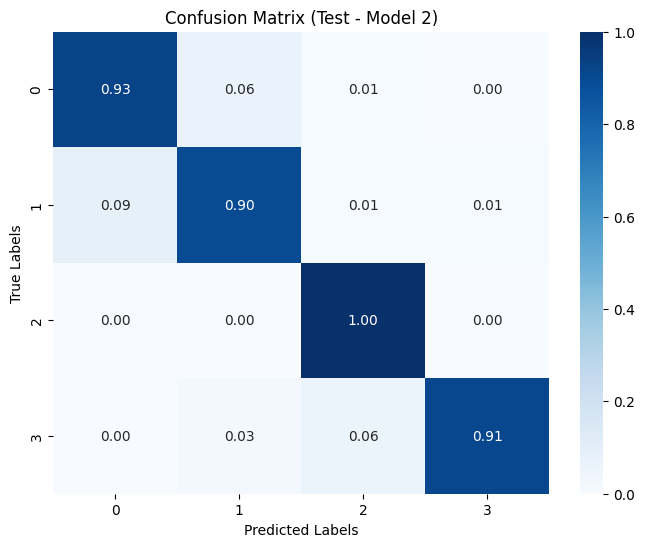


[== Evaluation on External - Model 2 Data ==]
External - Model 2 Loss: 1.1523
External - Model 2 Accuracy: 0.7617

Classification Report (External - Model 2 Data):
              precision    recall  f1-score   support

           0       0.71      0.79      0.74      1008
           1       0.27      0.98      0.43       229
           2       0.22      0.99      0.36       456
           3       1.00      0.74      0.85      9141

    accuracy                           0.76     10834
   macro avg       0.55      0.87      0.59     10834
weighted avg       0.92      0.76      0.81     10834

External - Model 2 AUC: 0.9649


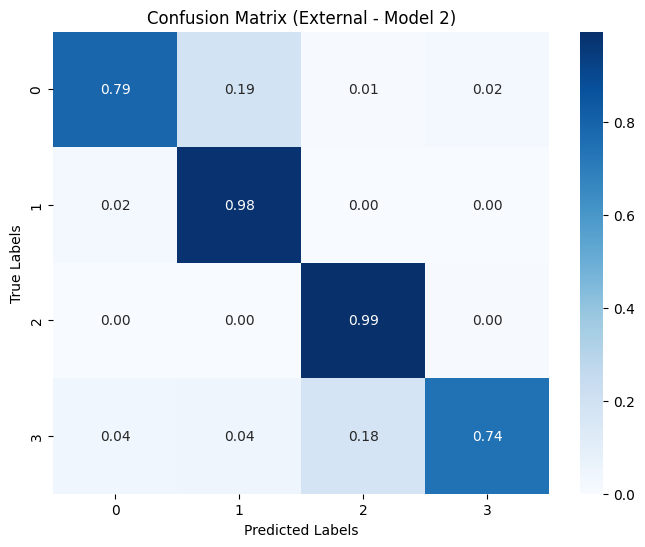

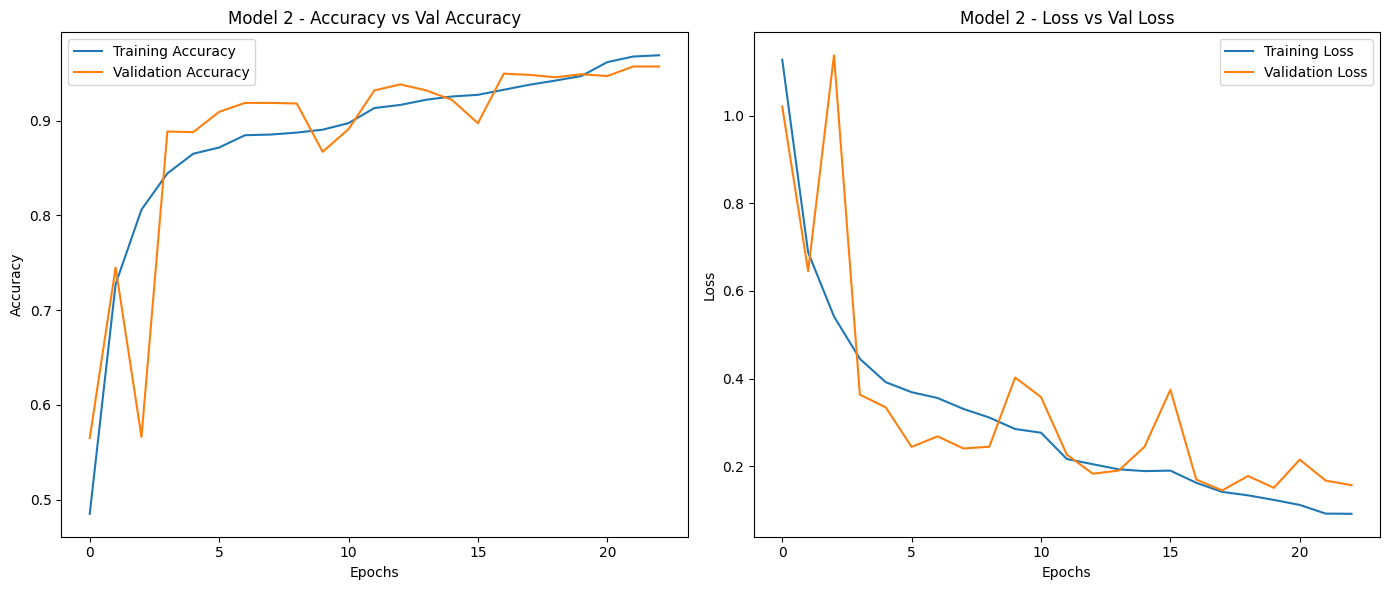


Model 2 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 3/30

Model 3 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.005217775571273986
  weight_decay: 0.005016261356061333
  batch_size: 32

=== Evaluating Model 3 ===

[== Evaluation on Test - Model 3 Data ==]
Test - Model 3 Loss: 0.1359
Test - Model 3 Accuracy: 0.9585

Classification Report (Test - Model 3 Data):
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       112
           1       0.92      0.93      0.93       115
           2       0.97      0.99      0.98       189
           3       0.99      0.94      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.95       530
weighted avg       0.96      0.96      0.96 

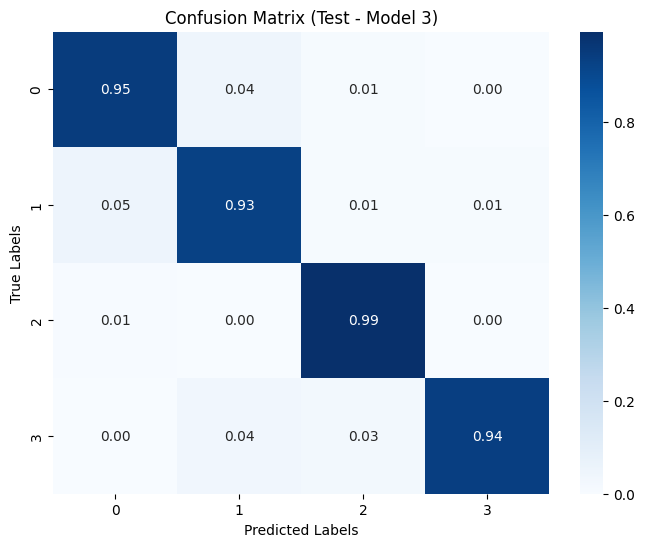


[== Evaluation on External - Model 3 Data ==]
External - Model 3 Loss: 1.0685
External - Model 3 Accuracy: 0.7282

Classification Report (External - Model 3 Data):
              precision    recall  f1-score   support

           0       0.48      0.79      0.60      1008
           1       0.21      0.93      0.35       229
           2       0.26      0.98      0.41       456
           3       1.00      0.70      0.82      9141

    accuracy                           0.73     10834
   macro avg       0.49      0.85      0.55     10834
weighted avg       0.90      0.73      0.78     10834

External - Model 3 AUC: 0.9537


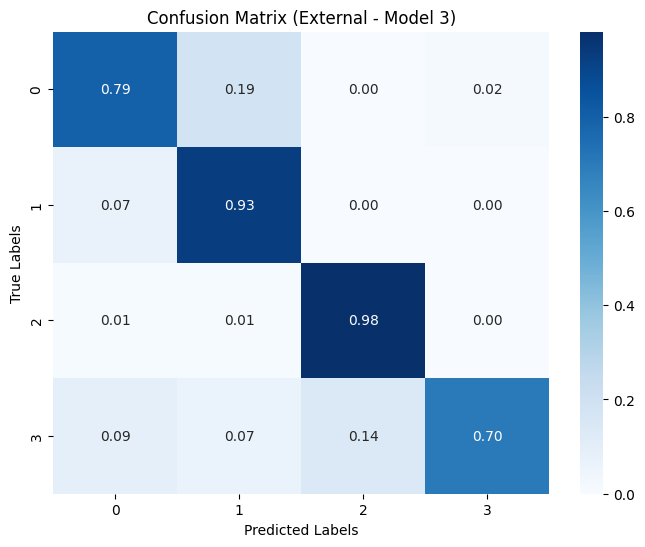

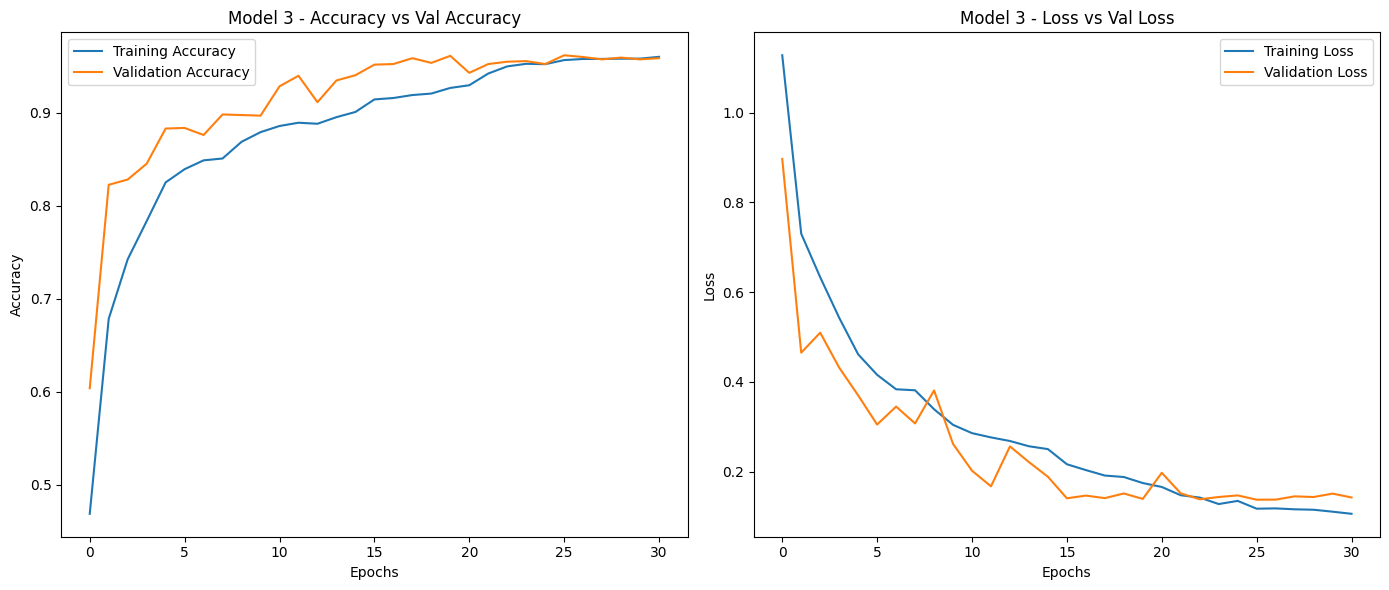


Model 3 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 4/30

Model 4 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.005495590855393051
  weight_decay: 0.0019887895210356386
  batch_size: 32

=== Evaluating Model 4 ===

[== Evaluation on Test - Model 4 Data ==]
Test - Model 4 Loss: 0.2301
Test - Model 4 Accuracy: 0.9585

Classification Report (Test - Model 4 Data):
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       112
           1       0.93      0.92      0.93       115
           2       0.99      0.98      0.99       189
           3       0.96      0.96      0.96       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96      0.96 

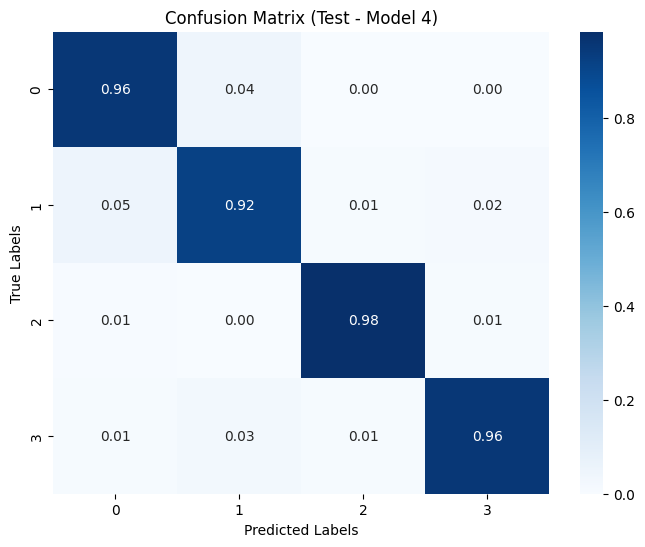


[== Evaluation on External - Model 4 Data ==]
External - Model 4 Loss: 1.6505
External - Model 4 Accuracy: 0.7695

Classification Report (External - Model 4 Data):
              precision    recall  f1-score   support

           0       0.54      0.79      0.64      1008
           1       0.26      0.93      0.41       229
           2       0.27      0.96      0.42       456
           3       0.99      0.75      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.52      0.86      0.58     10834
weighted avg       0.91      0.77      0.81     10834

External - Model 4 AUC: 0.9469


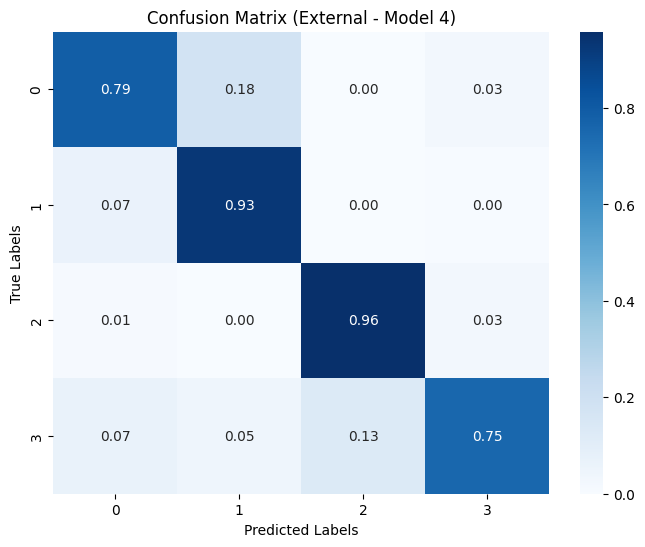

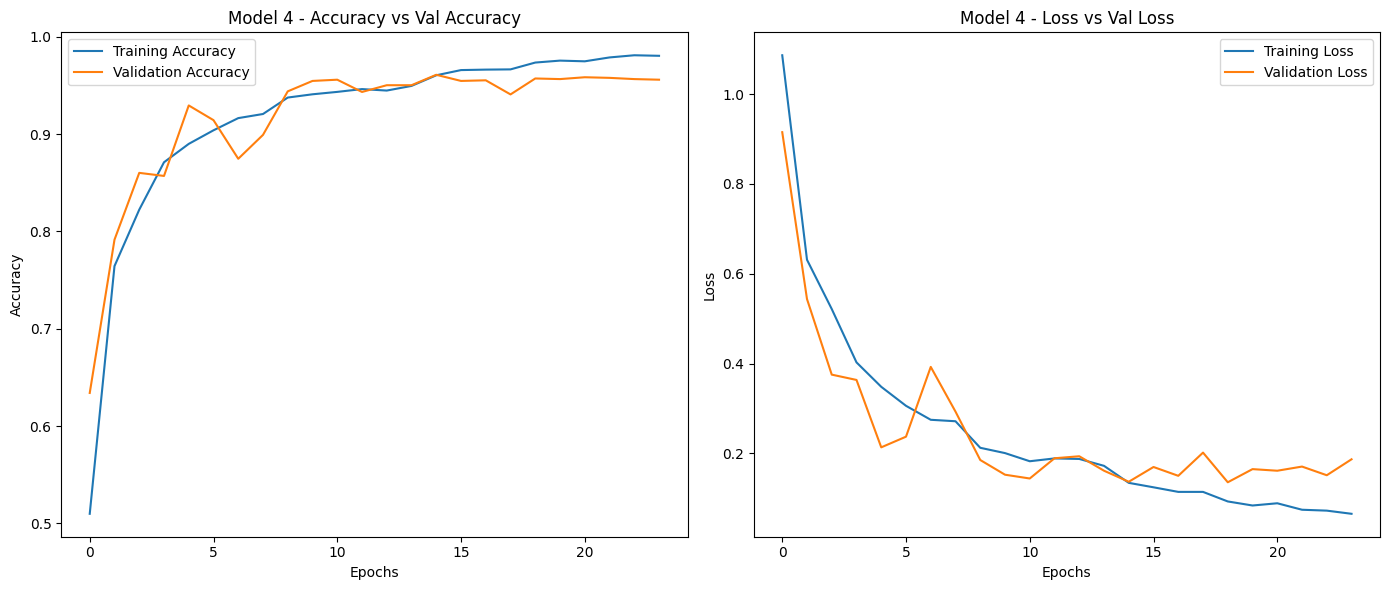


Model 4 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 5/30

Model 5 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.004801913363797763
  weight_decay: 0.003258117604194309
  batch_size: 32

=== Evaluating Model 5 ===

[== Evaluation on Test - Model 5 Data ==]
Test - Model 5 Loss: 0.1790
Test - Model 5 Accuracy: 0.9547

Classification Report (Test - Model 5 Data):
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       112
           1       0.94      0.89      0.91       115
           2       0.98      0.99      0.99       189
           3       0.98      0.94      0.96       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.95      0.95 

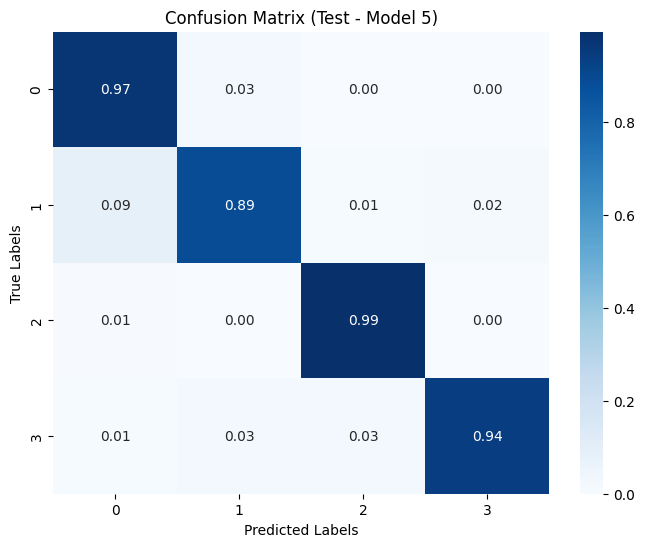


[== Evaluation on External - Model 5 Data ==]
External - Model 5 Loss: 1.1151
External - Model 5 Accuracy: 0.7887

Classification Report (External - Model 5 Data):
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1008
           1       0.26      0.94      0.41       229
           2       0.25      0.99      0.39       456
           3       1.00      0.78      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.56      0.86      0.60     10834
weighted avg       0.92      0.79      0.83     10834

External - Model 5 AUC: 0.9609


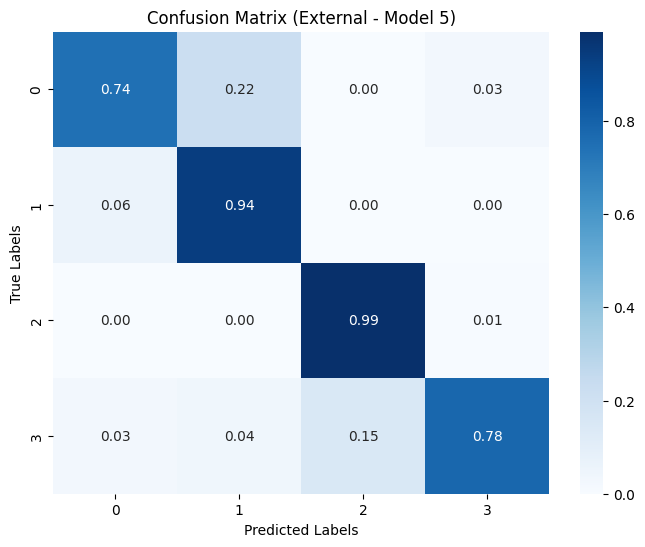

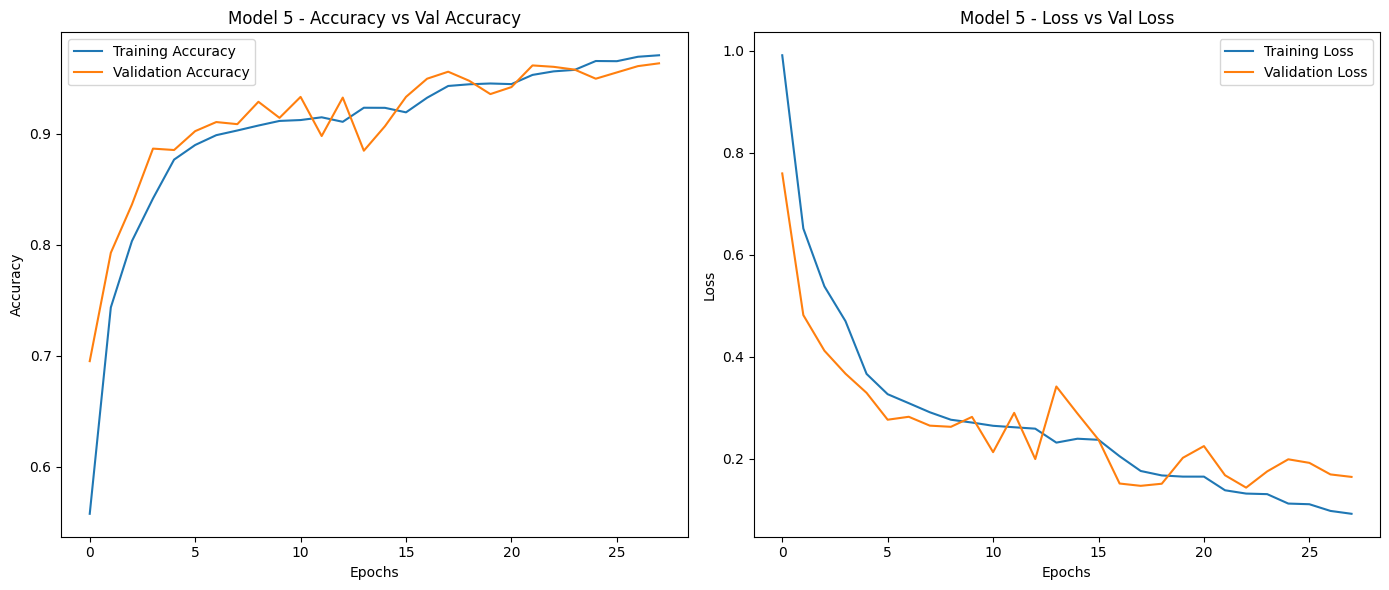


Model 5 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 6/30

Model 6 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.4
  learning_rate: 0.004166689576022923
  weight_decay: 0.008227989056629524
  batch_size: 32

=== Evaluating Model 6 ===

[== Evaluation on Test - Model 6 Data ==]
Test - Model 6 Loss: 0.1587
Test - Model 6 Accuracy: 0.9623

Classification Report (Test - Model 6 Data):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       112
           1       0.94      0.94      0.94       115
           2       0.97      0.99      0.98       189
           3       0.98      0.95      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96      0.96 

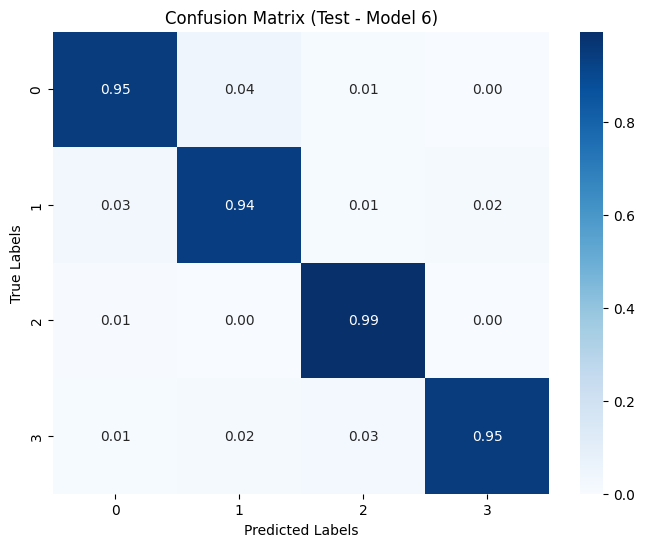


[== Evaluation on External - Model 6 Data ==]
External - Model 6 Loss: 1.1925
External - Model 6 Accuracy: 0.7520

Classification Report (External - Model 6 Data):
              precision    recall  f1-score   support

           0       0.55      0.74      0.63      1008
           1       0.23      0.97      0.37       229
           2       0.25      0.97      0.40       456
           3       0.99      0.74      0.85      9141

    accuracy                           0.75     10834
   macro avg       0.51      0.85      0.56     10834
weighted avg       0.91      0.75      0.80     10834

External - Model 6 AUC: 0.9549


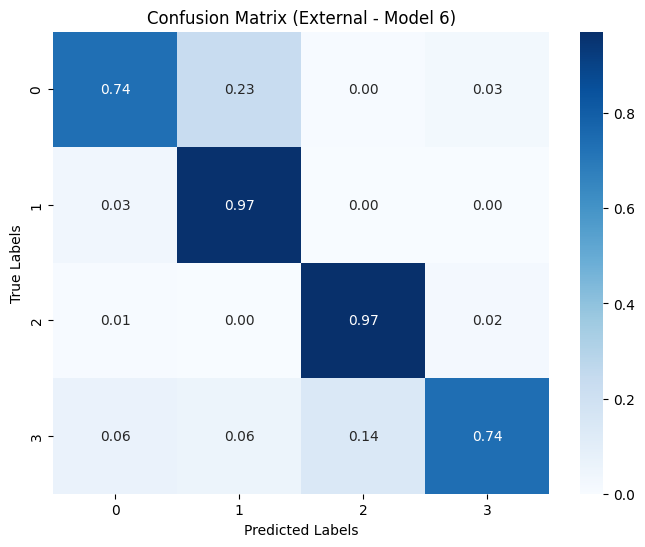

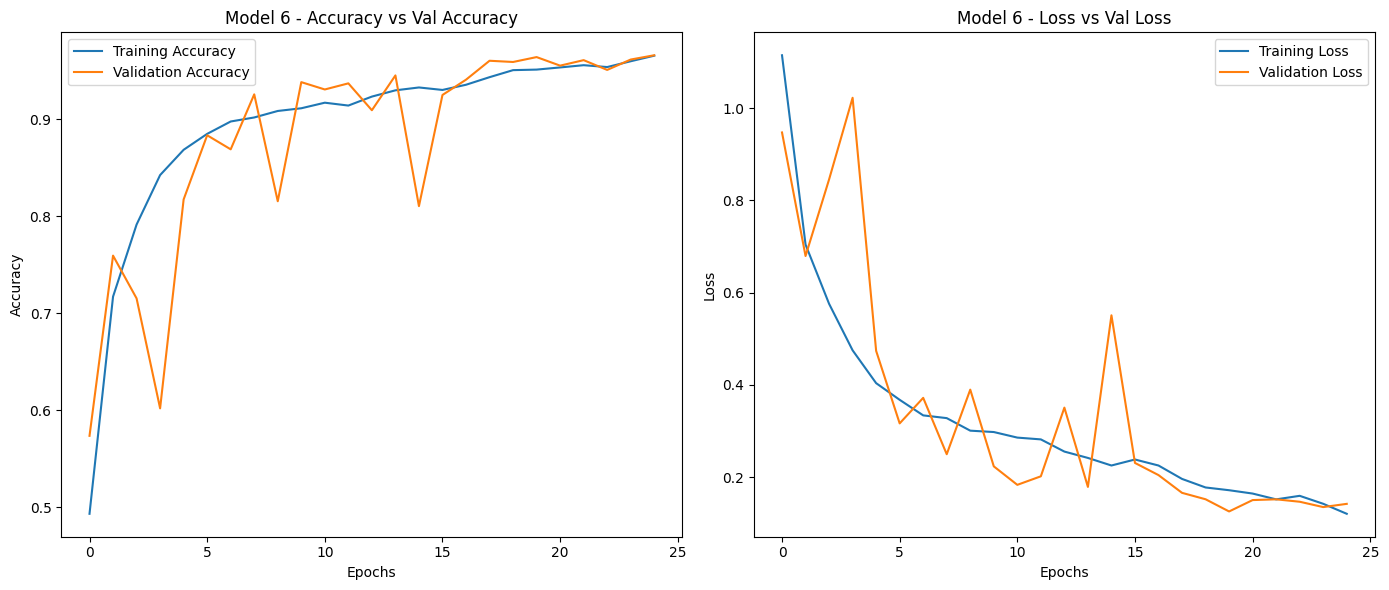


Model 6 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 7/30

Model 7 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.005721840034935886
  weight_decay: 0.004729715264087464
  batch_size: 32

=== Evaluating Model 7 ===

[== Evaluation on Test - Model 7 Data ==]
Test - Model 7 Loss: 0.1346
Test - Model 7 Accuracy: 0.9698

Classification Report (Test - Model 7 Data):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       112
           1       0.95      0.94      0.94       115
           2       0.98      1.00      0.99       189
           3       0.97      0.95      0.96       114

    accuracy                           0.97       530
   macro avg       0.97      0.96      0.97       530
weighted avg       0.97      0.97      0.97  

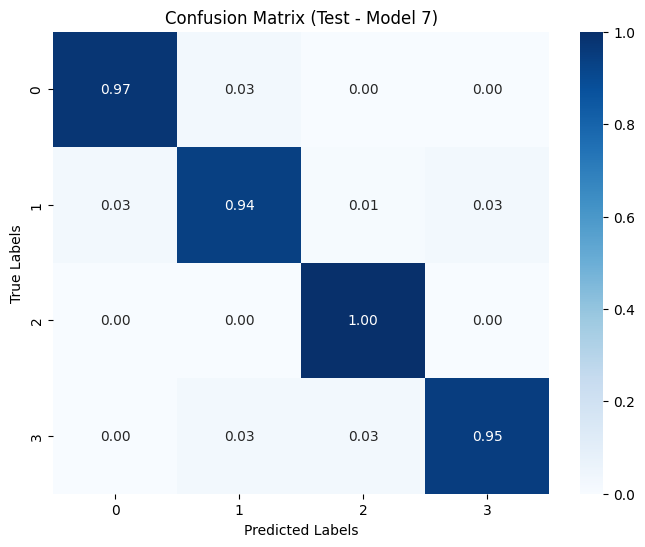


[== Evaluation on External - Model 7 Data ==]
External - Model 7 Loss: 0.7995
External - Model 7 Accuracy: 0.7932

Classification Report (External - Model 7 Data):
              precision    recall  f1-score   support

           0       0.71      0.74      0.73      1008
           1       0.27      0.99      0.42       229
           2       0.26      0.98      0.41       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.79     10834
   macro avg       0.56      0.87      0.61     10834
weighted avg       0.92      0.79      0.83     10834

External - Model 7 AUC: 0.9605


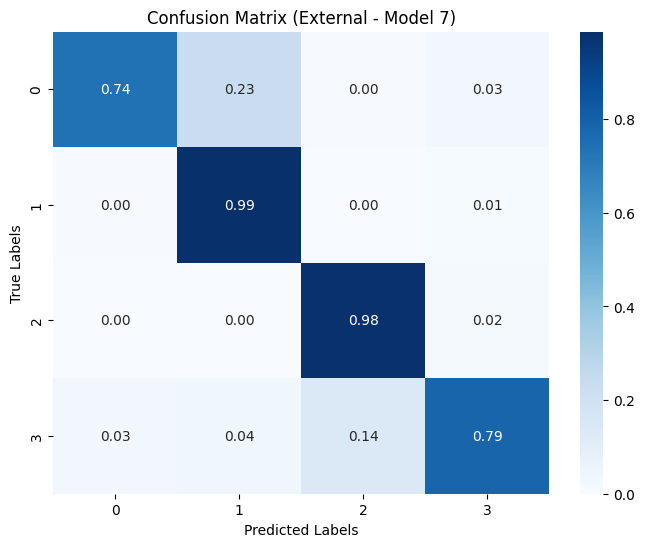

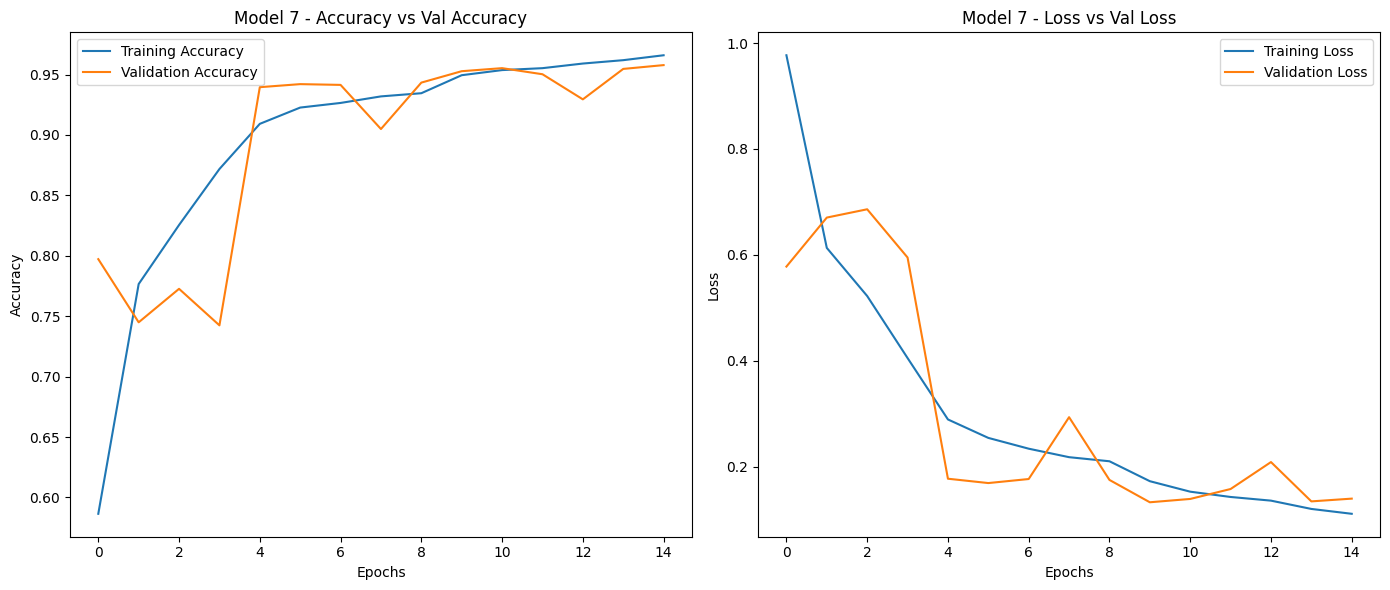


Model 7 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 8/30

Model 8 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.4
  learning_rate: 0.006578211980536039
  weight_decay: 0.009389285461251699
  batch_size: 32

=== Evaluating Model 8 ===

[== Evaluation on Test - Model 8 Data ==]
Test - Model 8 Loss: 0.1310
Test - Model 8 Accuracy: 0.9604

Classification Report (Test - Model 8 Data):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       112
           1       0.94      0.92      0.93       115
           2       0.98      0.99      0.99       189
           3       0.98      0.96      0.97       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96      0.96 

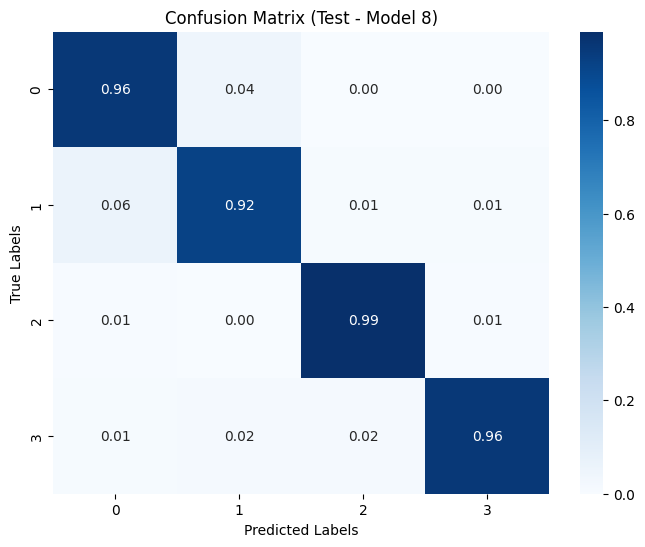


[== Evaluation on External - Model 8 Data ==]
External - Model 8 Loss: 1.2640
External - Model 8 Accuracy: 0.7736

Classification Report (External - Model 8 Data):
              precision    recall  f1-score   support

           0       0.54      0.76      0.63      1008
           1       0.27      0.94      0.42       229
           2       0.27      0.96      0.43       456
           3       1.00      0.76      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.52      0.86      0.58     10834
weighted avg       0.91      0.77      0.81     10834

External - Model 8 AUC: 0.9522


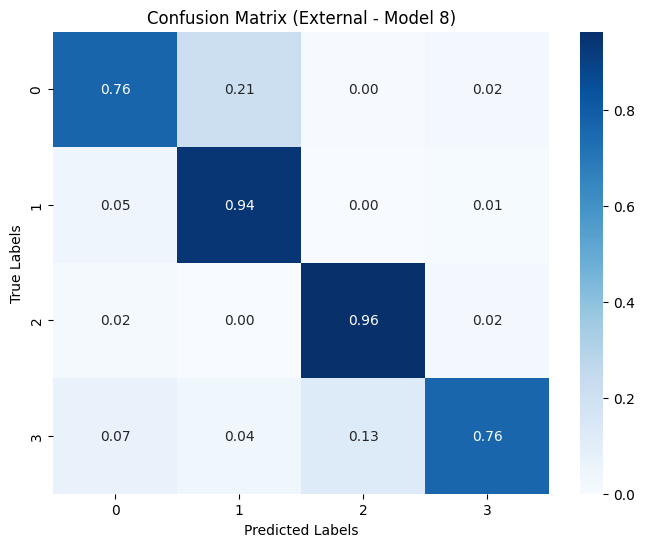

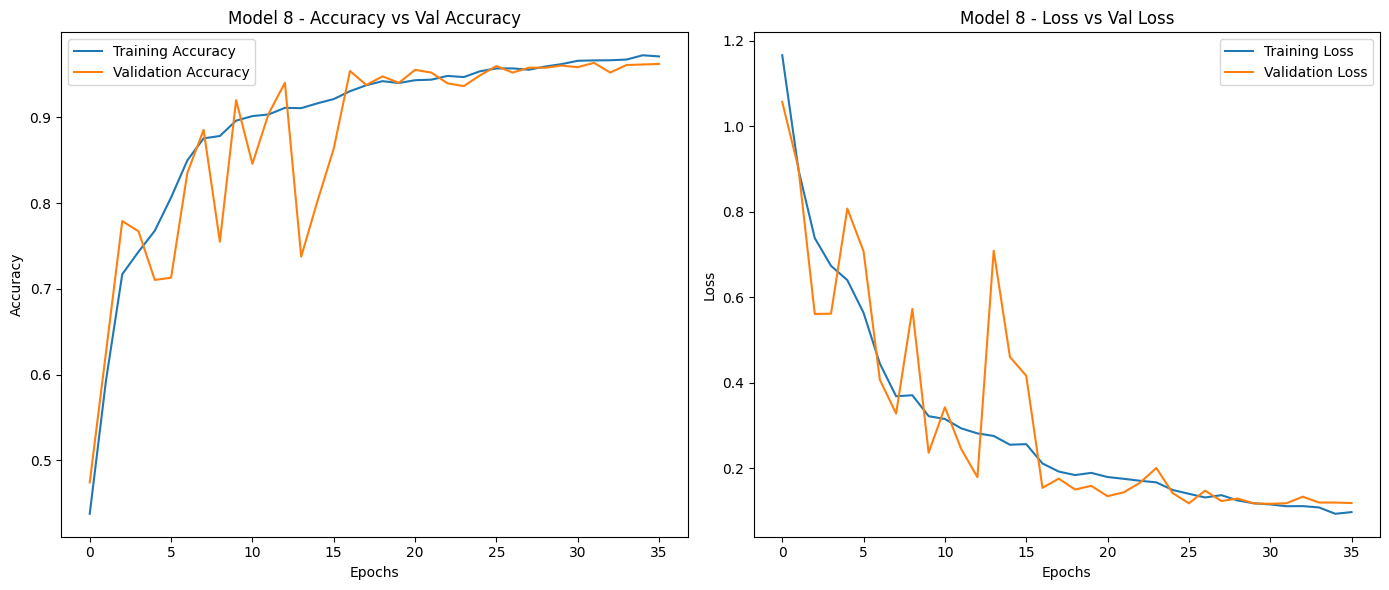


Model 8 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 9/30

Model 9 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.005323624114782333
  weight_decay: 0.004381377479826087
  batch_size: 32

=== Evaluating Model 9 ===

[== Evaluation on Test - Model 9 Data ==]
Test - Model 9 Loss: 0.1505
Test - Model 9 Accuracy: 0.9585

Classification Report (Test - Model 9 Data):
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       112
           1       0.92      0.93      0.93       115
           2       0.98      0.99      0.99       189
           3       0.95      0.96      0.95       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96      0.96  

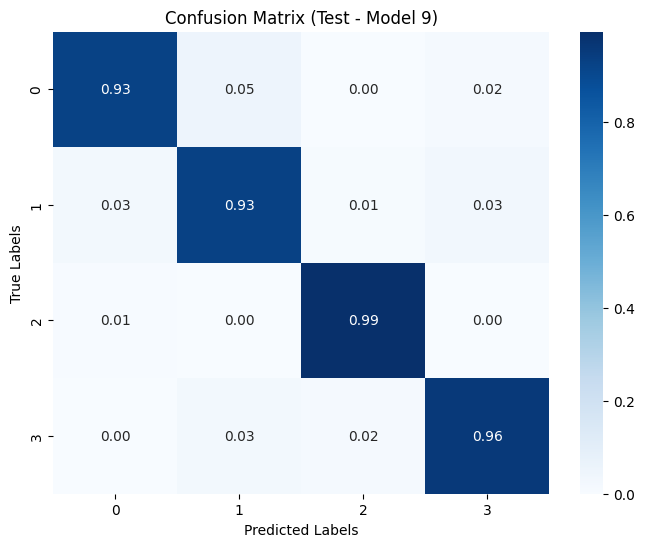


[== Evaluation on External - Model 9 Data ==]
External - Model 9 Loss: 1.0021
External - Model 9 Accuracy: 0.8082

Classification Report (External - Model 9 Data):
              precision    recall  f1-score   support

           0       0.88      0.74      0.80      1008
           1       0.26      0.95      0.41       229
           2       0.26      0.99      0.41       456
           3       0.99      0.80      0.89      9141

    accuracy                           0.81     10834
   macro avg       0.60      0.87      0.63     10834
weighted avg       0.93      0.81      0.85     10834

External - Model 9 AUC: 0.9593


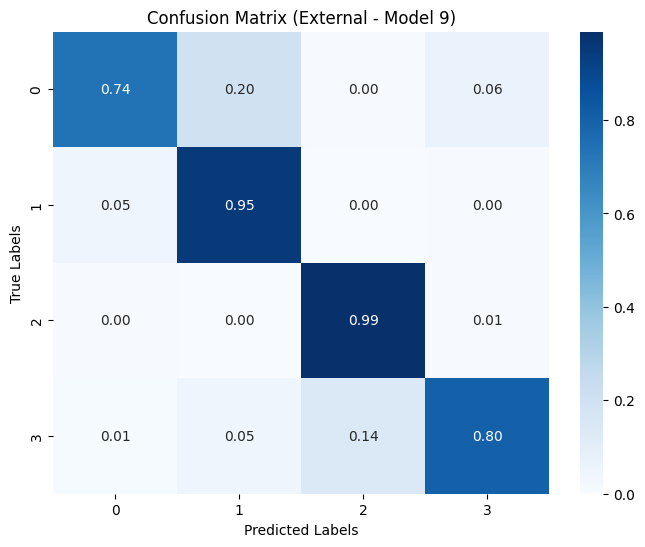

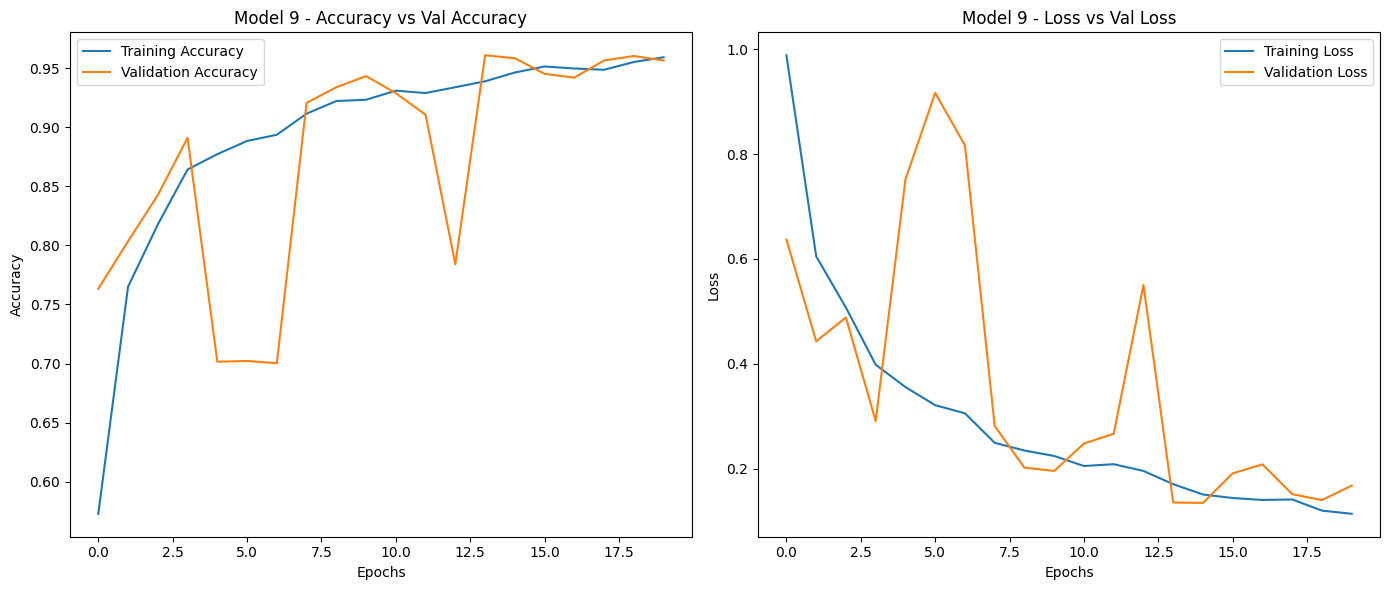


Model 9 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 10/30

Model 10 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.0028485109969904523
  weight_decay: 0.0053003136510103785
  batch_size: 32

=== Evaluating Model 10 ===

[== Evaluation on Test - Model 10 Data ==]
Test - Model 10 Loss: 0.1224
Test - Model 10 Accuracy: 0.9604

Classification Report (Test - Model 10 Data):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       112
           1       0.95      0.92      0.93       115
           2       0.96      1.00      0.98       189
           3       0.98      0.91      0.95       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.96       530
weighted avg       0.96      0.96   

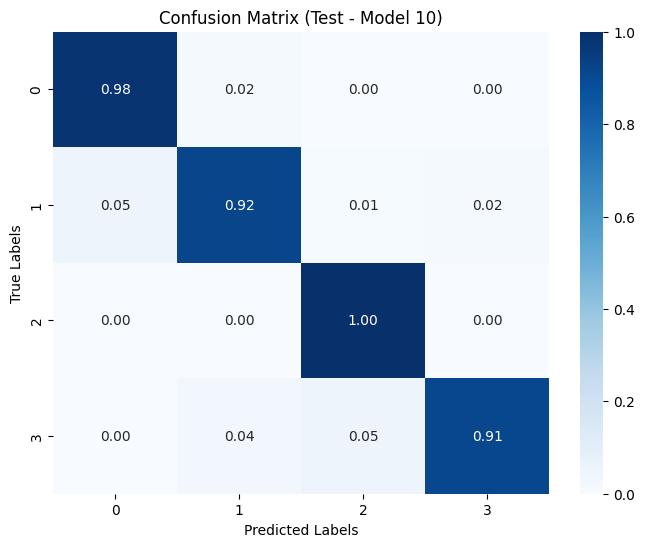


[== Evaluation on External - Model 10 Data ==]
External - Model 10 Loss: 0.9208
External - Model 10 Accuracy: 0.7848

Classification Report (External - Model 10 Data):
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1008
           1       0.25      0.96      0.40       229
           2       0.25      0.98      0.39       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.56      0.87      0.60     10834
weighted avg       0.92      0.78      0.83     10834

External - Model 10 AUC: 0.9637


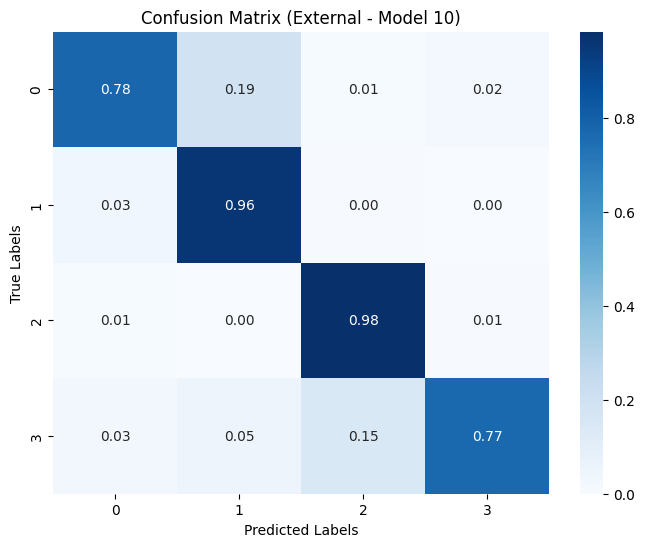

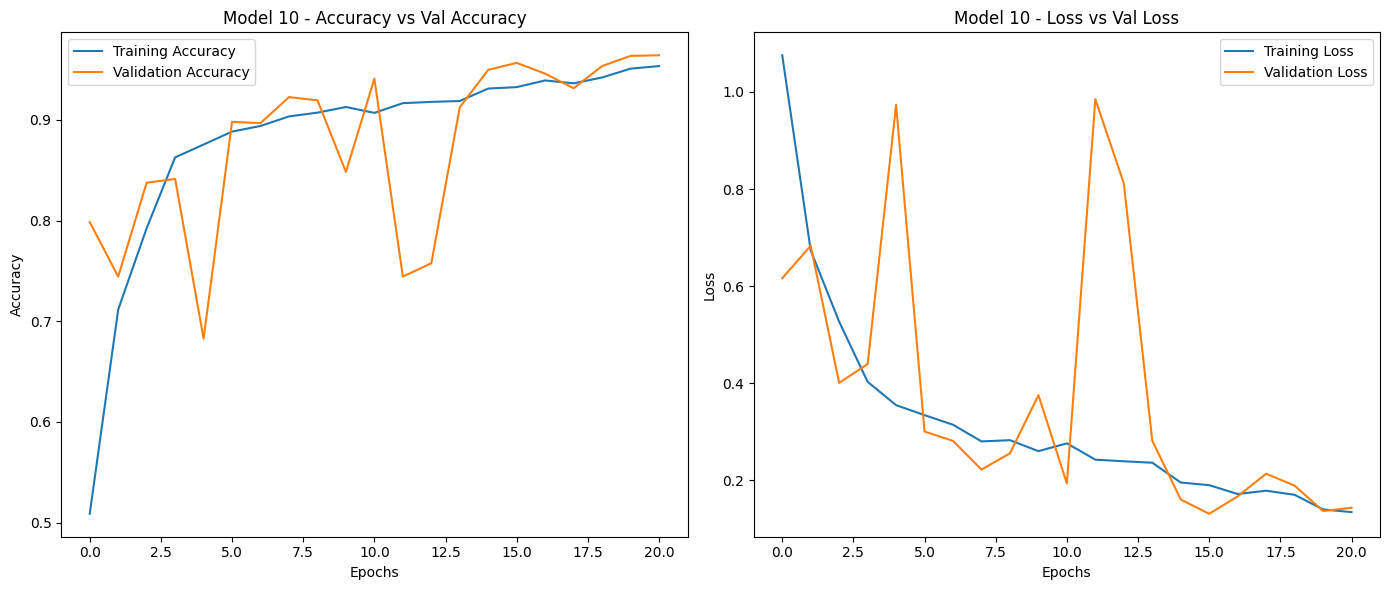


Model 10 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 11/30

Model 11 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.0045922784221724645
  weight_decay: 0.007899031364660308
  batch_size: 32

=== Evaluating Model 11 ===

[== Evaluation on Test - Model 11 Data ==]
Test - Model 11 Loss: 0.1579
Test - Model 11 Accuracy: 0.9623

Classification Report (Test - Model 11 Data):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       112
           1       0.94      0.93      0.93       115
           2       0.97      0.99      0.98       189
           3       0.98      0.94      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96  

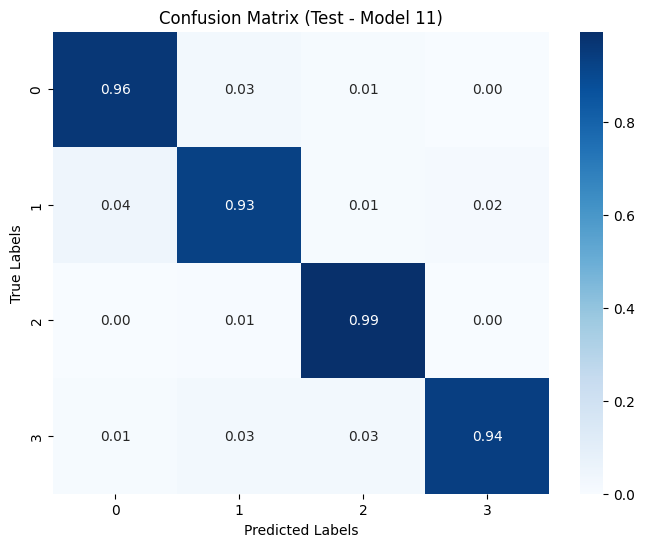


[== Evaluation on External - Model 11 Data ==]
External - Model 11 Loss: 1.2607
External - Model 11 Accuracy: 0.7526

Classification Report (External - Model 11 Data):
              precision    recall  f1-score   support

           0       0.51      0.78      0.62      1008
           1       0.25      0.97      0.40       229
           2       0.26      0.96      0.41       456
           3       0.99      0.73      0.84      9141

    accuracy                           0.75     10834
   macro avg       0.50      0.86      0.57     10834
weighted avg       0.90      0.75      0.80     10834

External - Model 11 AUC: 0.9514


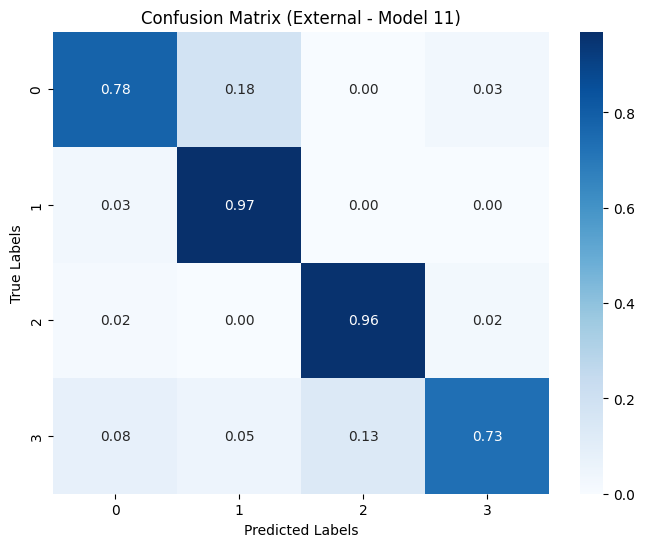

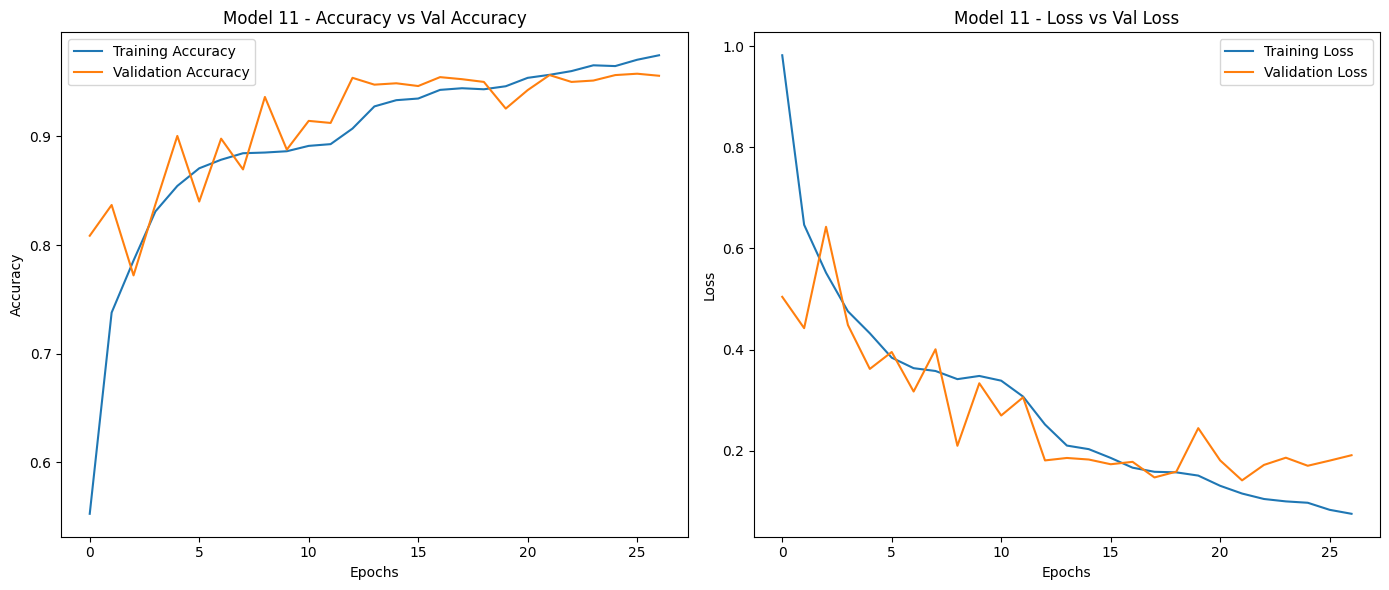


Model 11 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 12/30

Model 12 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.005031804505299233
  weight_decay: 0.006833064124643628
  batch_size: 32

=== Evaluating Model 12 ===

[== Evaluation on Test - Model 12 Data ==]
Test - Model 12 Loss: 0.1768
Test - Model 12 Accuracy: 0.9547

Classification Report (Test - Model 12 Data):
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       112
           1       0.94      0.93      0.93       115
           2       0.96      0.99      0.98       189
           3       0.99      0.91      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.95  

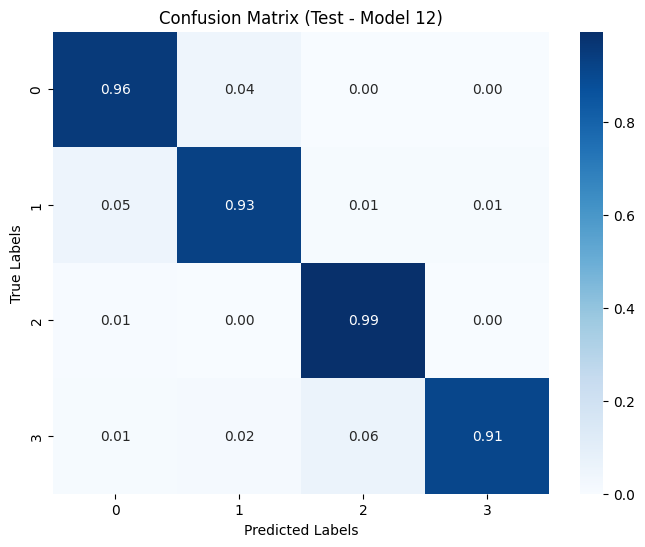


[== Evaluation on External - Model 12 Data ==]
External - Model 12 Loss: 1.2096
External - Model 12 Accuracy: 0.7756

Classification Report (External - Model 12 Data):
              precision    recall  f1-score   support

           0       0.84      0.72      0.77      1008
           1       0.25      0.98      0.40       229
           2       0.22      0.99      0.36       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.58      0.86      0.60     10834
weighted avg       0.93      0.78      0.83     10834

External - Model 12 AUC: 0.9616


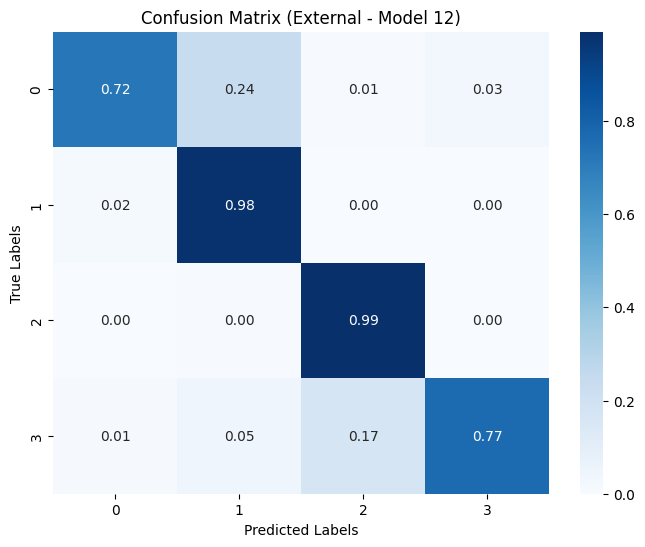

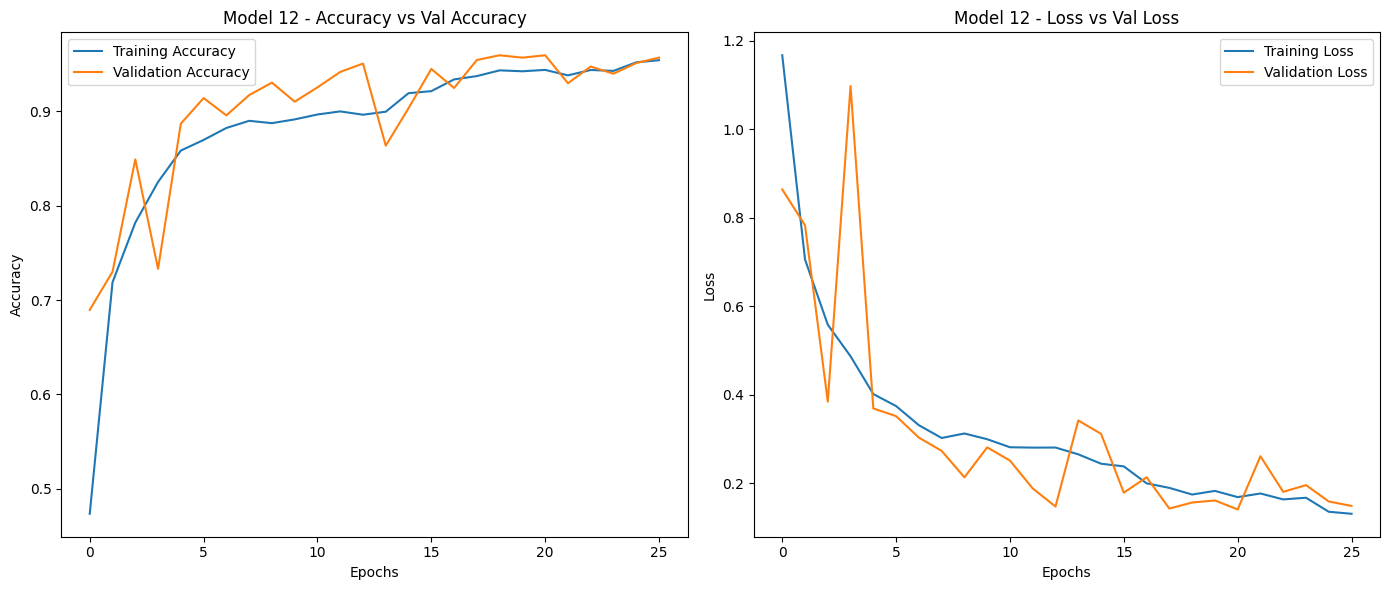


Model 12 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 13/30

Model 13 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.45
  learning_rate: 0.0034152070261895765
  weight_decay: 0.009116322401863781
  batch_size: 32

=== Evaluating Model 13 ===

[== Evaluation on Test - Model 13 Data ==]
Test - Model 13 Loss: 0.2073
Test - Model 13 Accuracy: 0.9585

Classification Report (Test - Model 13 Data):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       112
           1       0.94      0.90      0.92       115
           2       0.98      0.99      0.98       189
           3       0.97      0.95      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.95       530
weighted avg       0.96      0.96 

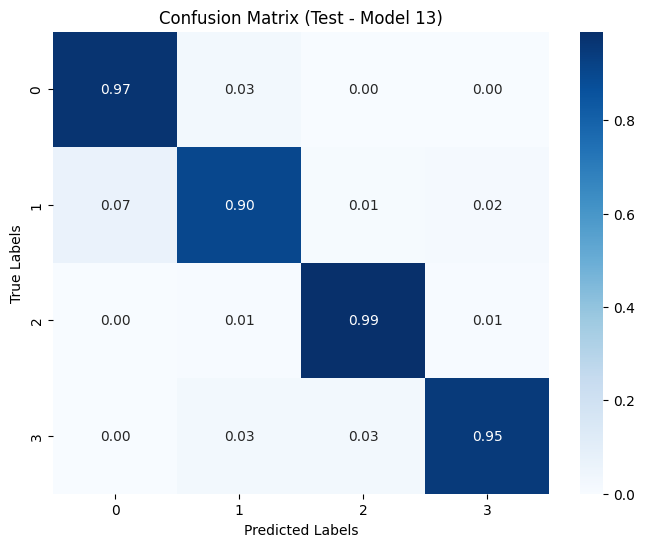


[== Evaluation on External - Model 13 Data ==]
External - Model 13 Loss: 1.6874
External - Model 13 Accuracy: 0.8010

Classification Report (External - Model 13 Data):
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      1008
           1       0.27      0.97      0.43       229
           2       0.25      0.98      0.40       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.80     10834
   macro avg       0.58      0.87      0.62     10834
weighted avg       0.93      0.80      0.84     10834

External - Model 13 AUC: 0.9610


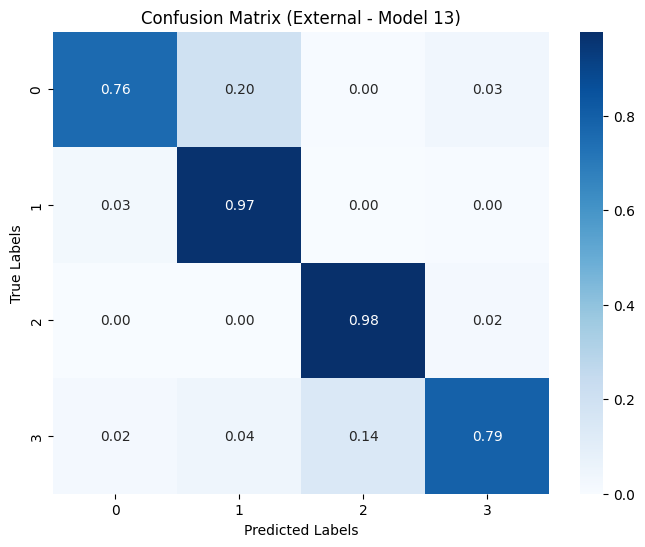

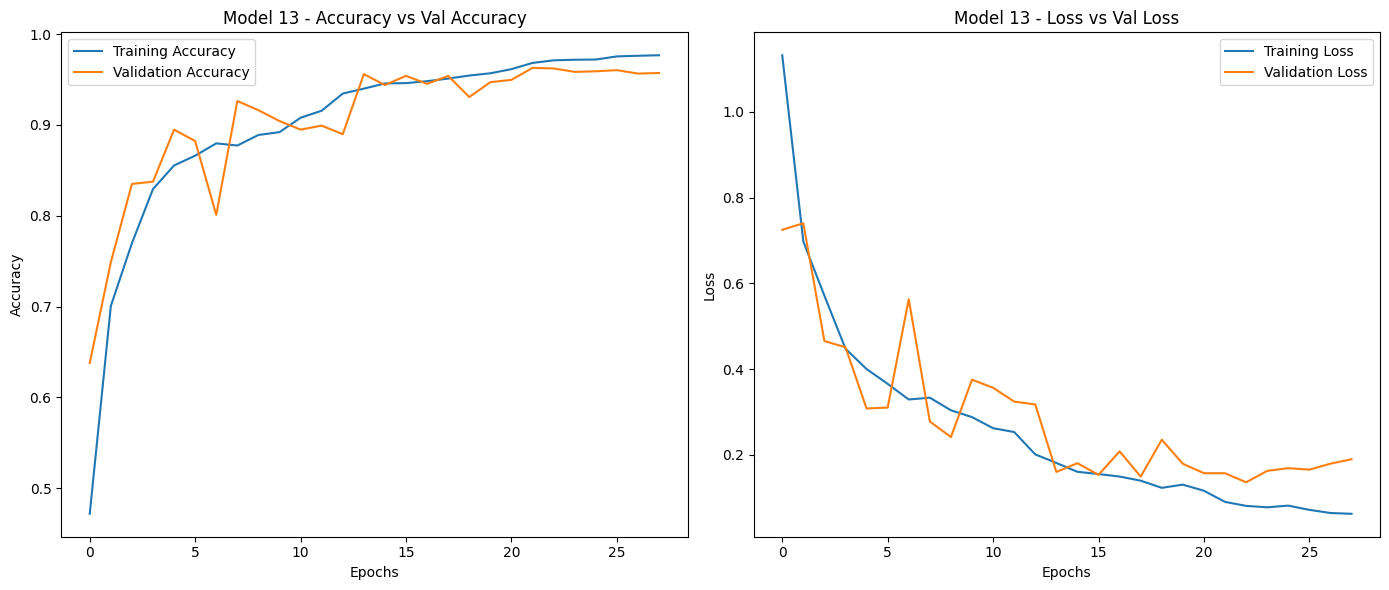


Model 13 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 14/30

Model 14 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.005469648207160343
  weight_decay: 0.006645607743522296
  batch_size: 32

=== Evaluating Model 14 ===

[== Evaluation on Test - Model 14 Data ==]
Test - Model 14 Loss: 0.1359
Test - Model 14 Accuracy: 0.9566

Classification Report (Test - Model 14 Data):
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       112
           1       0.94      0.91      0.93       115
           2       0.98      0.99      0.99       189
           3       0.96      0.95      0.95       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96  

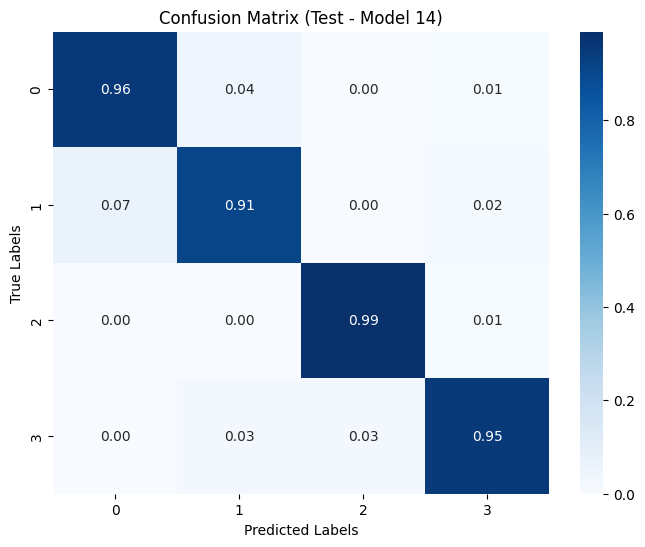


[== Evaluation on External - Model 14 Data ==]
External - Model 14 Loss: 0.9883
External - Model 14 Accuracy: 0.7693

Classification Report (External - Model 14 Data):
              precision    recall  f1-score   support

           0       0.56      0.81      0.66      1008
           1       0.31      0.94      0.47       229
           2       0.25      0.98      0.40       456
           3       1.00      0.75      0.86      9141

    accuracy                           0.77     10834
   macro avg       0.53      0.87      0.60     10834
weighted avg       0.91      0.77      0.81     10834

External - Model 14 AUC: 0.9580


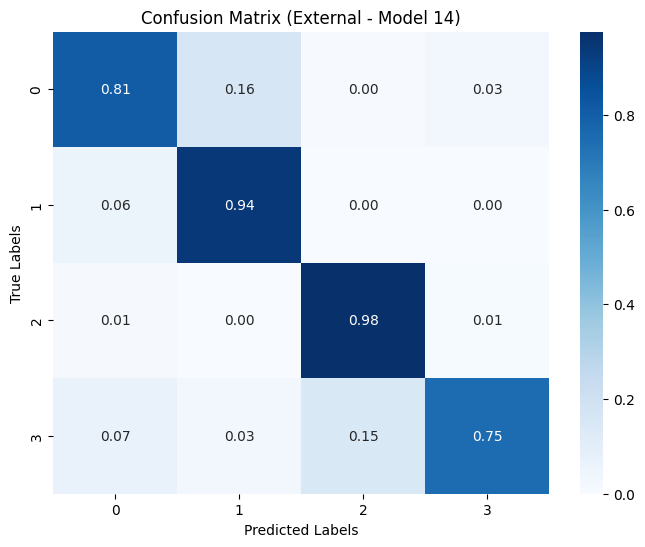

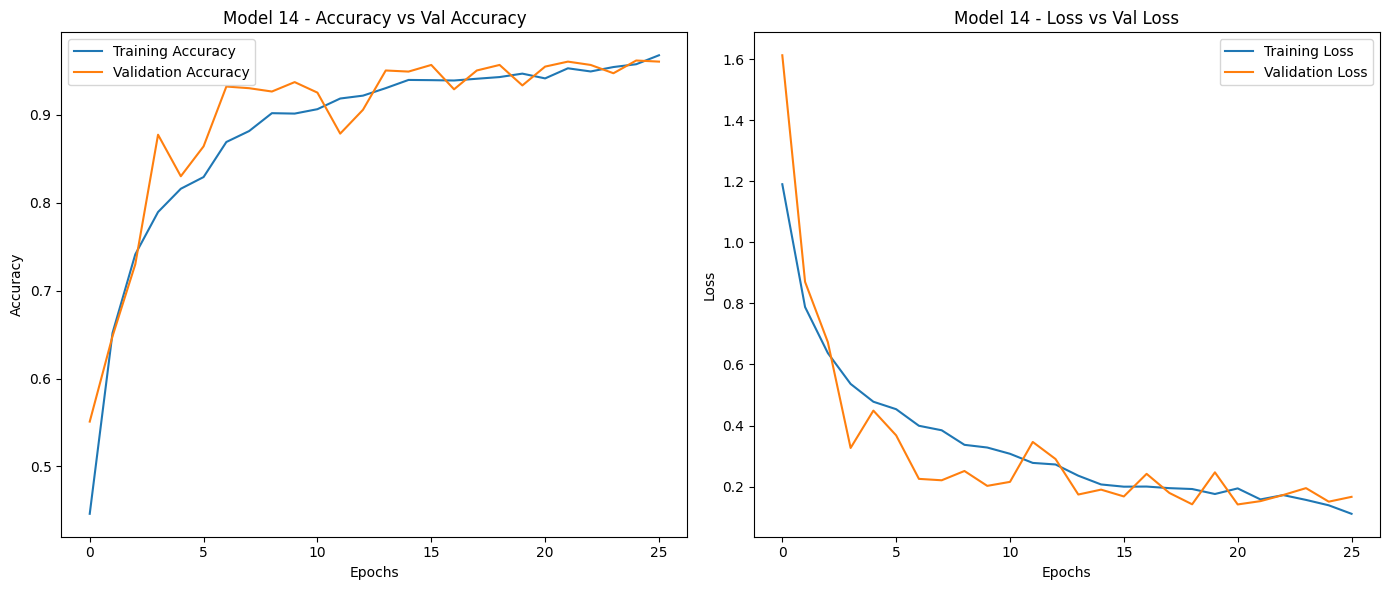


Model 14 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 15/30

Model 15 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.004720513384811585
  weight_decay: 0.006404093083058887
  batch_size: 32

=== Evaluating Model 15 ===

[== Evaluation on Test - Model 15 Data ==]
Test - Model 15 Loss: 0.1459
Test - Model 15 Accuracy: 0.9642

Classification Report (Test - Model 15 Data):
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       112
           1       0.92      0.94      0.93       115
           2       0.98      0.99      0.99       189
           3       0.99      0.95      0.97       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96   

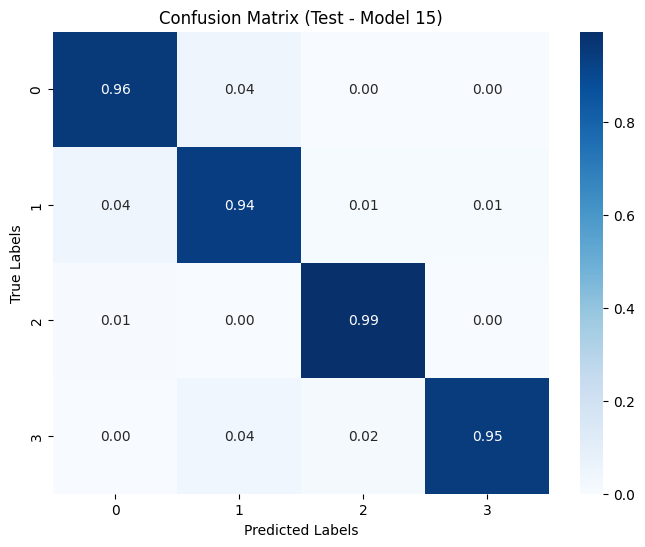


[== Evaluation on External - Model 15 Data ==]
External - Model 15 Loss: 0.8958
External - Model 15 Accuracy: 0.7838

Classification Report (External - Model 15 Data):
              precision    recall  f1-score   support

           0       0.66      0.80      0.72      1008
           1       0.25      0.96      0.39       229
           2       0.27      0.97      0.42       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.54      0.88      0.60     10834
weighted avg       0.92      0.78      0.82     10834

External - Model 15 AUC: 0.9596


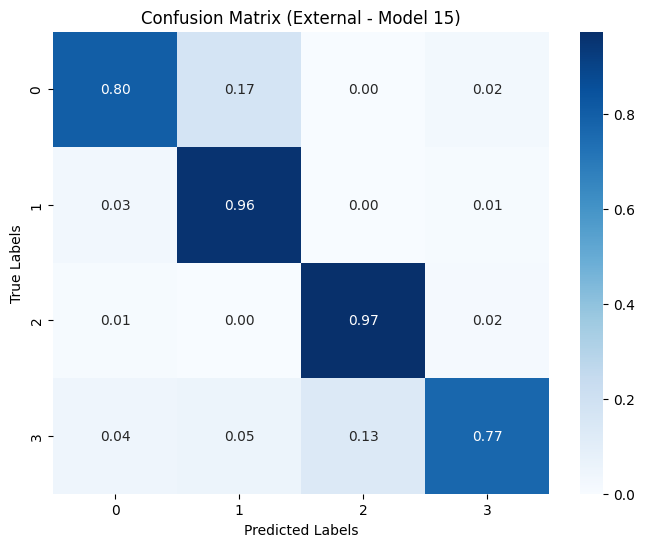

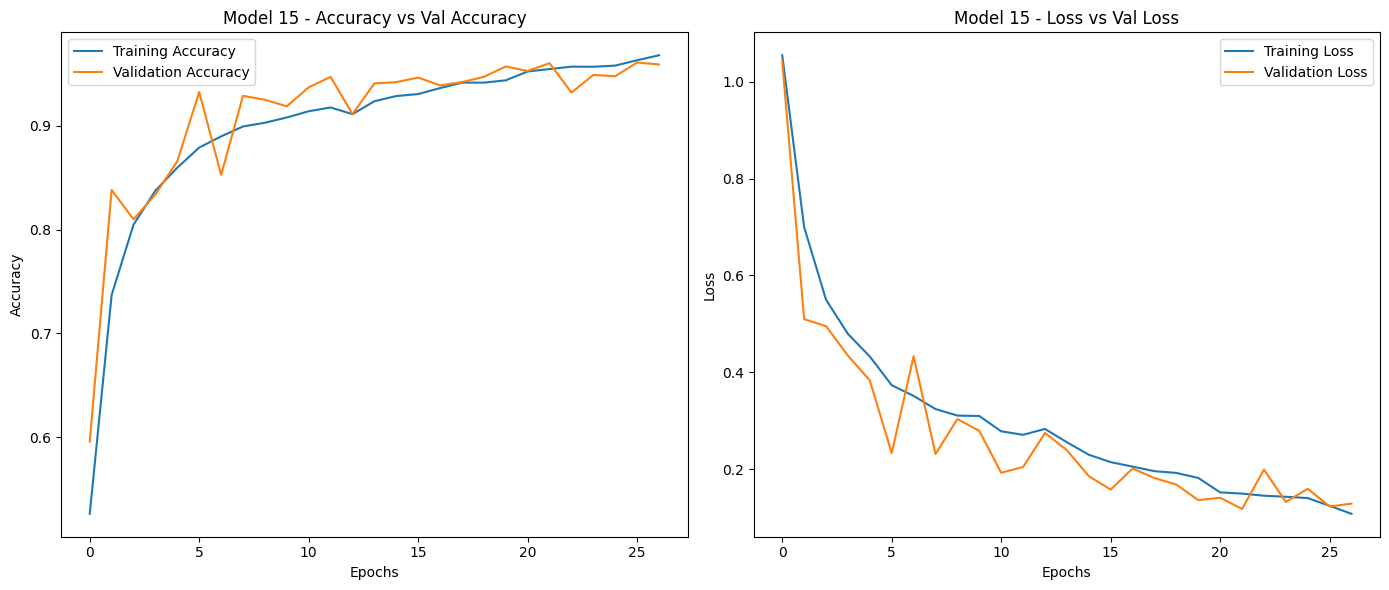


Model 15 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 16/30

Model 16 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.35
  learning_rate: 0.004802671253839719
  weight_decay: 0.004511140616122415
  batch_size: 32

=== Evaluating Model 16 ===

[== Evaluation on Test - Model 16 Data ==]
Test - Model 16 Loss: 0.1433
Test - Model 16 Accuracy: 0.9623

Classification Report (Test - Model 16 Data):
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       112
           1       0.97      0.91      0.94       115
           2       0.97      0.99      0.98       189
           3       0.99      0.95      0.97       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96  

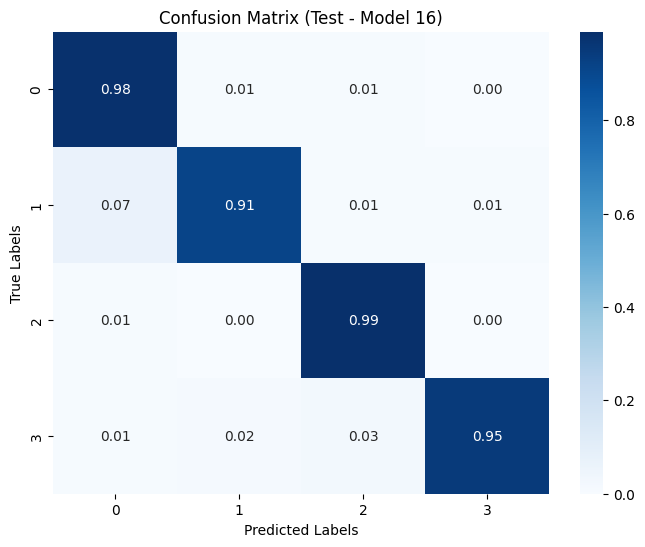


[== Evaluation on External - Model 16 Data ==]
External - Model 16 Loss: 1.3900
External - Model 16 Accuracy: 0.7778

Classification Report (External - Model 16 Data):
              precision    recall  f1-score   support

           0       0.65      0.83      0.73      1008
           1       0.27      0.90      0.42       229
           2       0.25      0.99      0.39       456
           3       1.00      0.76      0.86      9141

    accuracy                           0.78     10834
   macro avg       0.54      0.87      0.60     10834
weighted avg       0.92      0.78      0.82     10834

External - Model 16 AUC: 0.9557


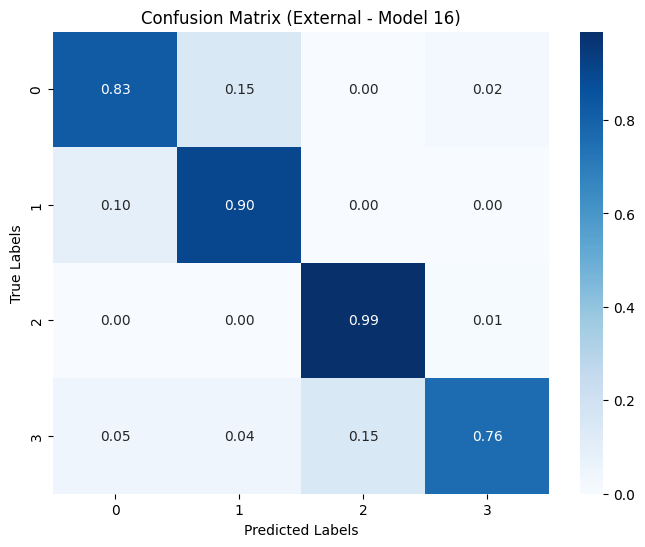

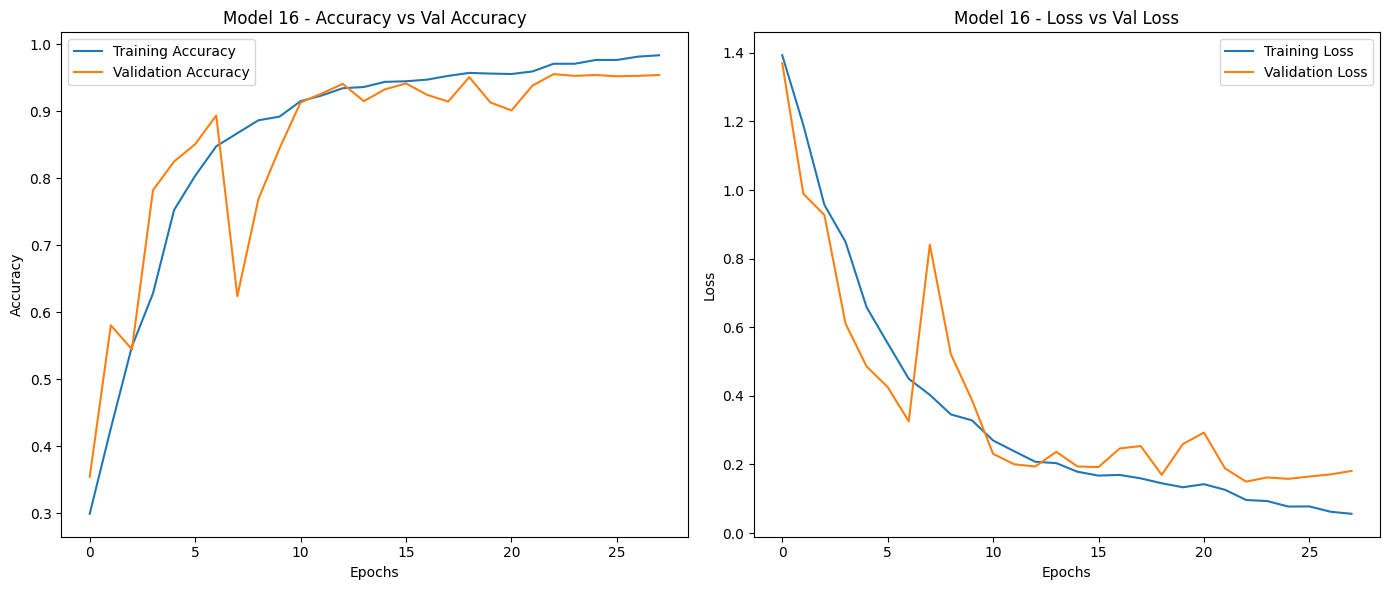


Model 16 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 17/30

Model 17 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.35
  learning_rate: 0.00511496882879869
  weight_decay: 0.0058312945523018534
  batch_size: 32

=== Evaluating Model 17 ===

[== Evaluation on Test - Model 17 Data ==]
Test - Model 17 Loss: 0.1374
Test - Model 17 Accuracy: 0.9566

Classification Report (Test - Model 17 Data):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       112
           1       0.96      0.92      0.94       115
           2       0.95      0.99      0.97       189
           3       0.99      0.91      0.95       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.95       530
weighted avg       0.96      0.96  

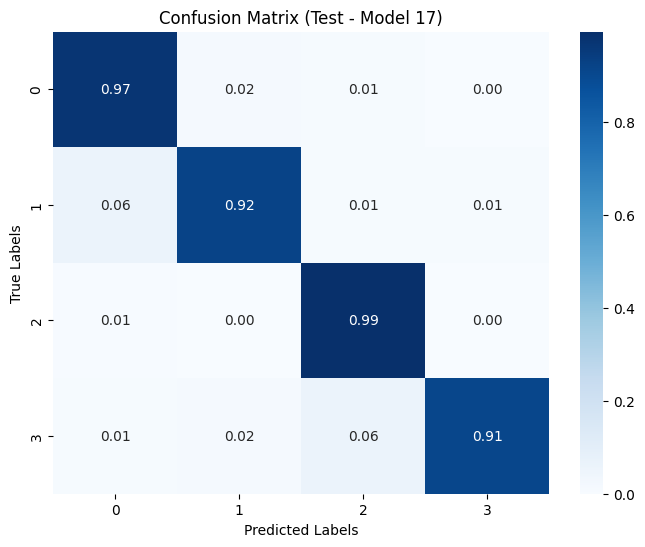


[== Evaluation on External - Model 17 Data ==]
External - Model 17 Loss: 0.8829
External - Model 17 Accuracy: 0.7845

Classification Report (External - Model 17 Data):
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1008
           1       0.24      0.98      0.39       229
           2       0.25      0.98      0.39       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.56      0.87      0.60     10834
weighted avg       0.93      0.78      0.83     10834

External - Model 17 AUC: 0.9680


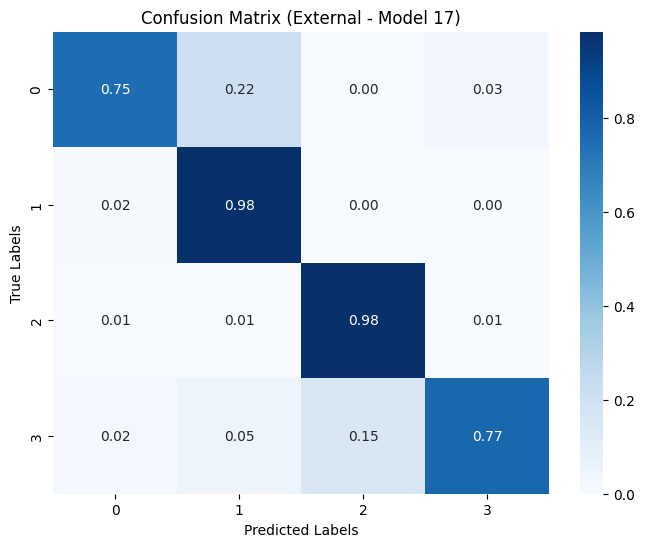

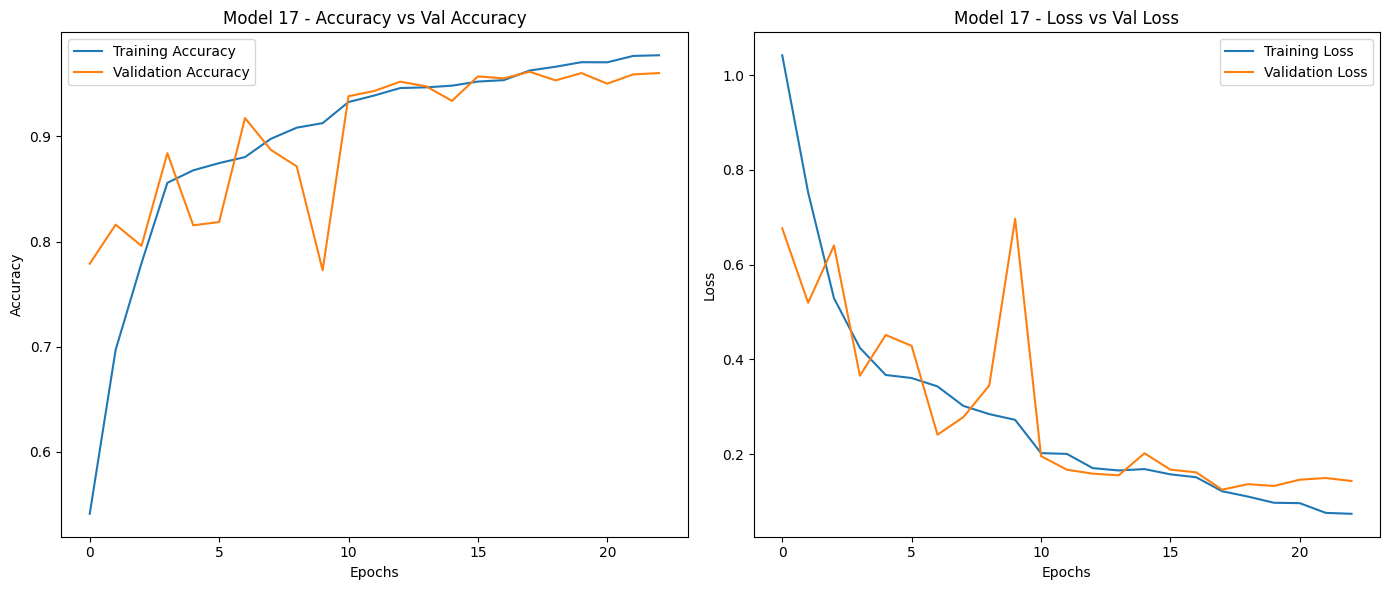


Model 17 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 18/30

Model 18 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.4
  dense_units_2: 32
  dropout_2: 0.4
  learning_rate: 0.00509702802958998
  weight_decay: 0.006888995520846903
  batch_size: 32

=== Evaluating Model 18 ===

[== Evaluation on Test - Model 18 Data ==]
Test - Model 18 Loss: 0.1888
Test - Model 18 Accuracy: 0.9642

Classification Report (Test - Model 18 Data):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       112
           1       0.94      0.95      0.94       115
           2       0.97      1.00      0.98       189
           3       0.98      0.93      0.95       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96     

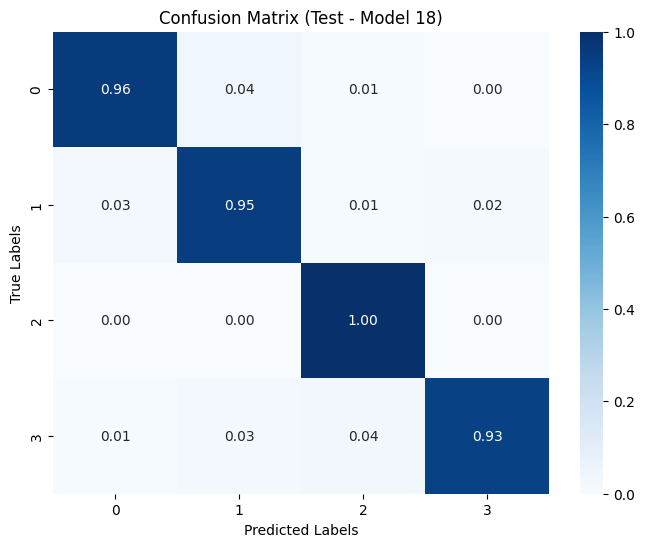


[== Evaluation on External - Model 18 Data ==]
External - Model 18 Loss: 1.8030
External - Model 18 Accuracy: 0.7141

Classification Report (External - Model 18 Data):
              precision    recall  f1-score   support

           0       0.40      0.72      0.52      1008
           1       0.22      0.94      0.35       229
           2       0.26      0.97      0.42       456
           3       1.00      0.70      0.82      9141

    accuracy                           0.71     10834
   macro avg       0.47      0.83      0.53     10834
weighted avg       0.89      0.71      0.76     10834

External - Model 18 AUC: 0.9367


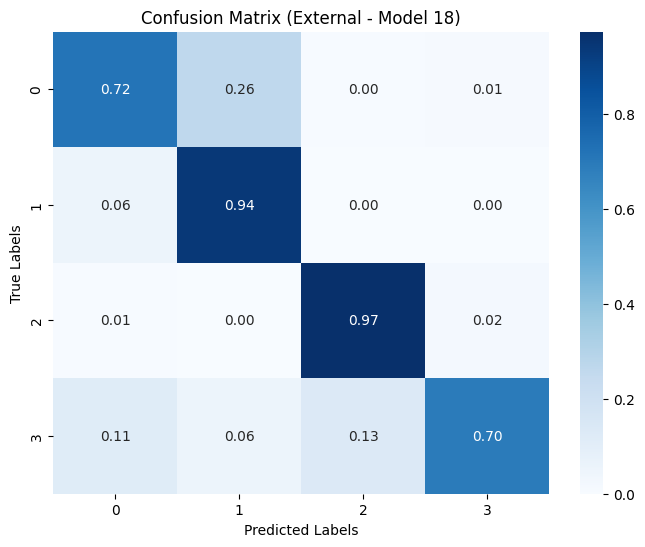

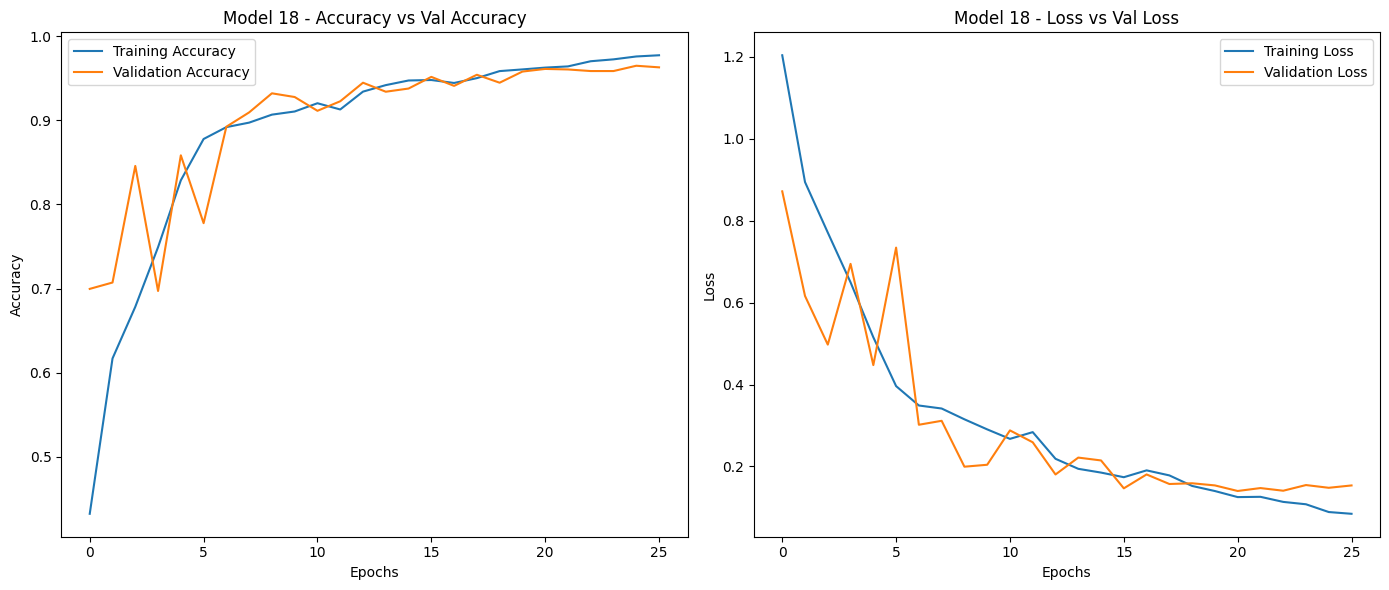


Model 18 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 19/30

Model 19 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.005155451361331478
  weight_decay: 0.006243162821156275
  batch_size: 32

=== Evaluating Model 19 ===

[== Evaluation on Test - Model 19 Data ==]
Test - Model 19 Loss: 0.1381
Test - Model 19 Accuracy: 0.9660

Classification Report (Test - Model 19 Data):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       112
           1       0.94      0.94      0.94       115
           2       0.98      0.99      0.99       189
           3       0.99      0.96      0.98       114

    accuracy                           0.97       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.97      0.97    

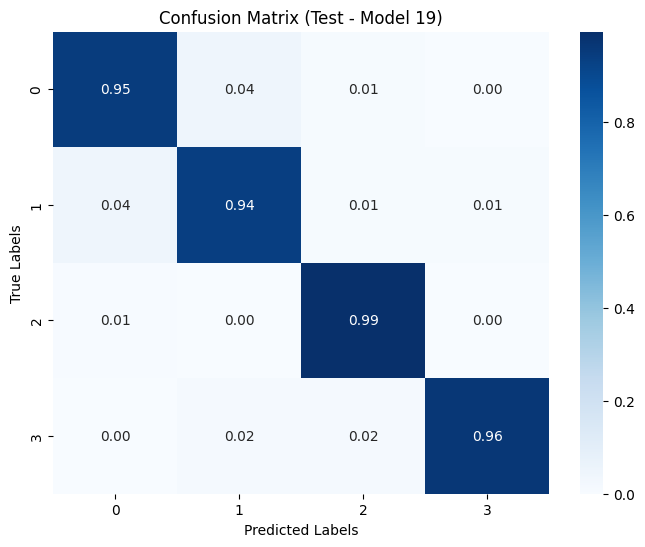


[== Evaluation on External - Model 19 Data ==]
External - Model 19 Loss: 1.1740
External - Model 19 Accuracy: 0.7813

Classification Report (External - Model 19 Data):
              precision    recall  f1-score   support

           0       0.64      0.76      0.69      1008
           1       0.27      0.96      0.42       229
           2       0.26      0.98      0.41       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.54      0.87      0.60     10834
weighted avg       0.92      0.78      0.82     10834

External - Model 19 AUC: 0.9585


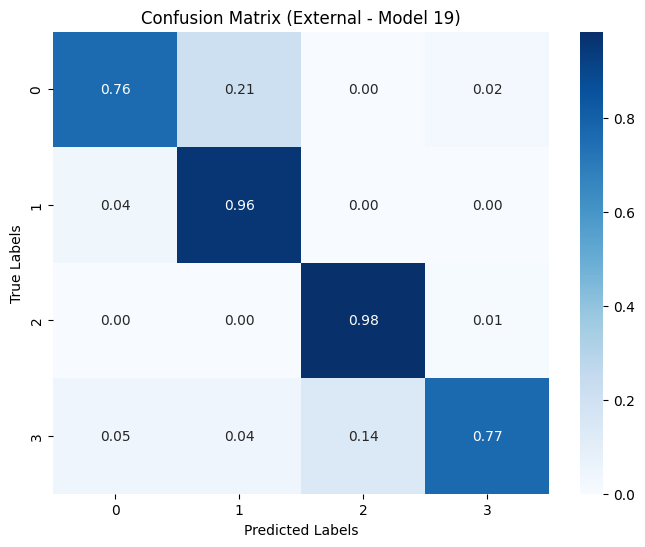

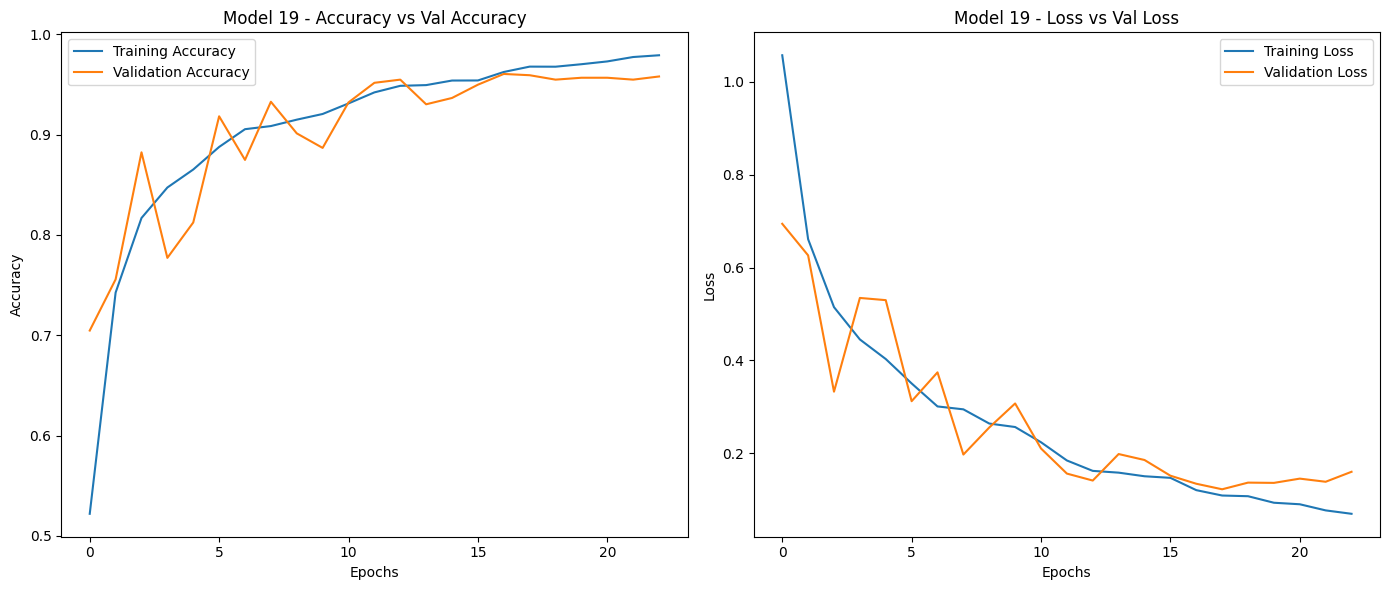


Model 19 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 20/30

Model 20 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 64
  dropout_2: 0.5
  learning_rate: 0.007888537372399354
  weight_decay: 0.008176858384238084
  batch_size: 32

=== Evaluating Model 20 ===

[== Evaluation on Test - Model 20 Data ==]
Test - Model 20 Loss: 0.1918
Test - Model 20 Accuracy: 0.9528

Classification Report (Test - Model 20 Data):
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       112
           1       0.95      0.91      0.93       115
           2       0.97      0.99      0.98       189
           3       0.96      0.94      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.95      0.95    

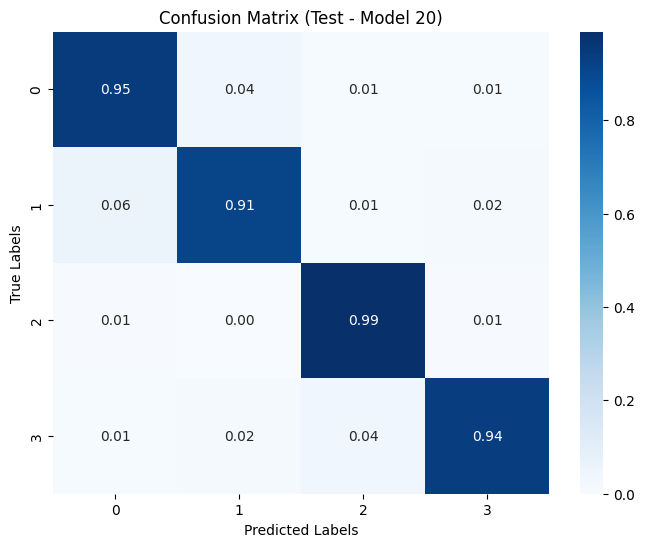


[== Evaluation on External - Model 20 Data ==]
External - Model 20 Loss: 0.9149
External - Model 20 Accuracy: 0.8080

Classification Report (External - Model 20 Data):
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1008
           1       0.26      0.97      0.42       229
           2       0.27      0.98      0.42       456
           3       0.99      0.80      0.89      9141

    accuracy                           0.81     10834
   macro avg       0.58      0.88      0.63     10834
weighted avg       0.93      0.81      0.85     10834

External - Model 20 AUC: 0.9667


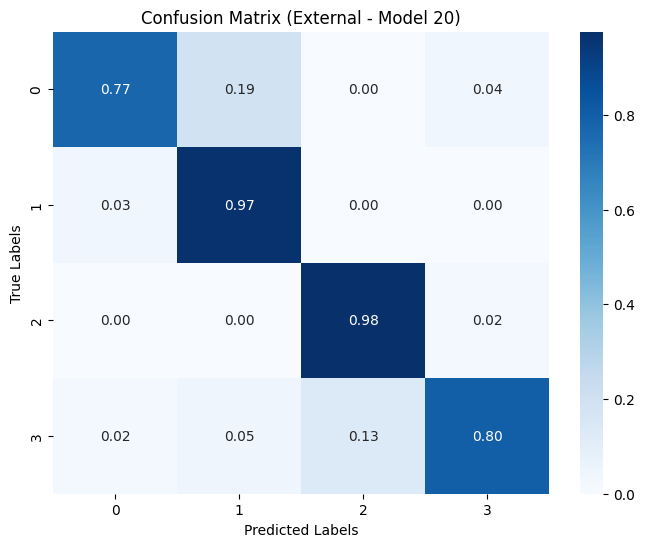

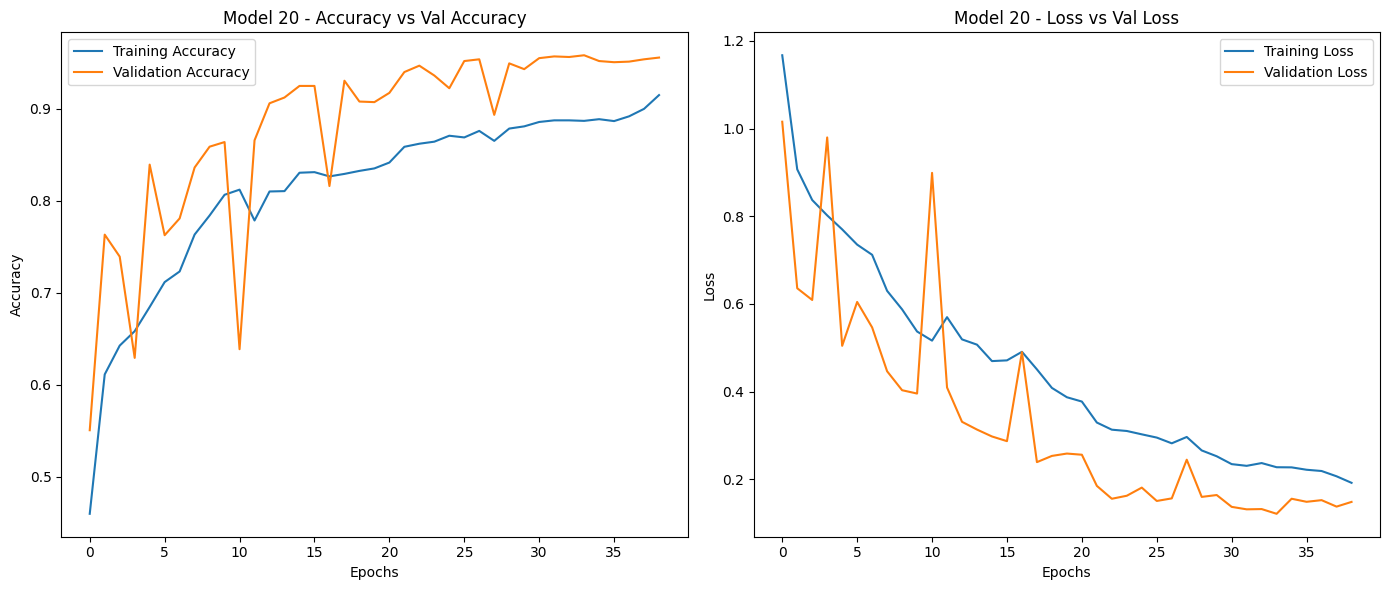


Model 20 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 21/30

Model 21 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 2
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.3
  learning_rate: 0.005475576562465996
  weight_decay: 0.004446207344924676
  batch_size: 32

=== Evaluating Model 21 ===

[== Evaluation on Test - Model 21 Data ==]
Test - Model 21 Loss: 0.1679
Test - Model 21 Accuracy: 0.9585

Classification Report (Test - Model 21 Data):
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       112
           1       0.93      0.93      0.93       115
           2       0.98      0.98      0.98       189
           3       0.96      0.95      0.95       114

    accuracy                           0.96       530
   macro avg       0.95      0.96      0.95       530
weighted avg       0.96      0.96   

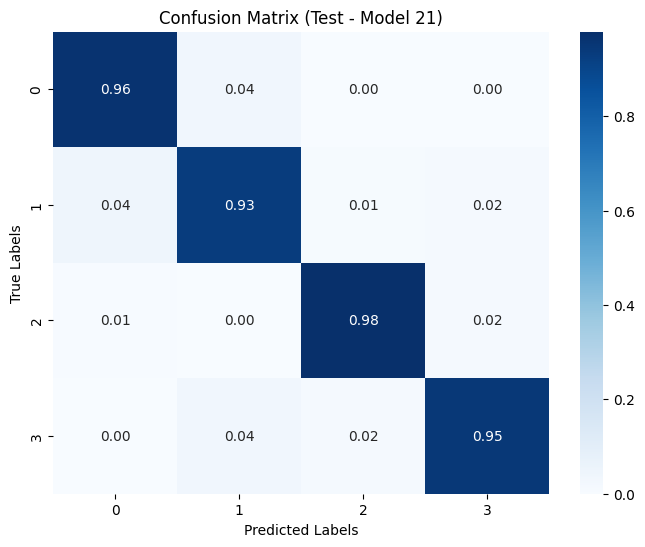


[== Evaluation on External - Model 21 Data ==]
External - Model 21 Loss: 1.0125
External - Model 21 Accuracy: 0.7893

Classification Report (External - Model 21 Data):
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      1008
           1       0.27      0.97      0.42       229
           2       0.26      0.96      0.41       456
           3       0.99      0.77      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.55      0.88      0.61     10834
weighted avg       0.92      0.79      0.83     10834

External - Model 21 AUC: 0.9570


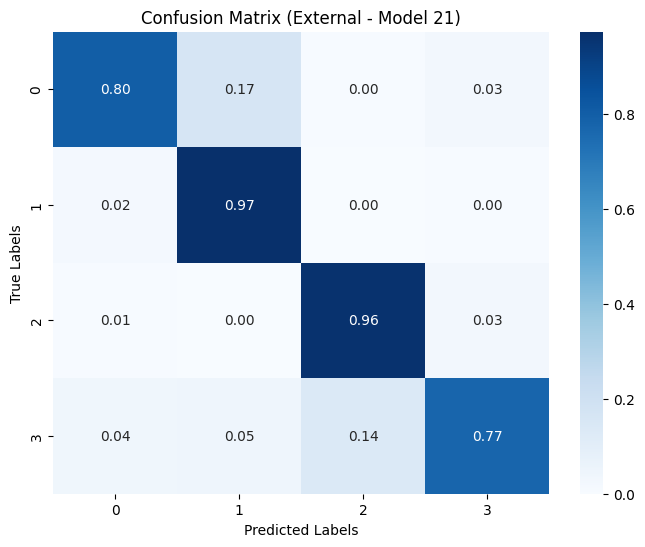

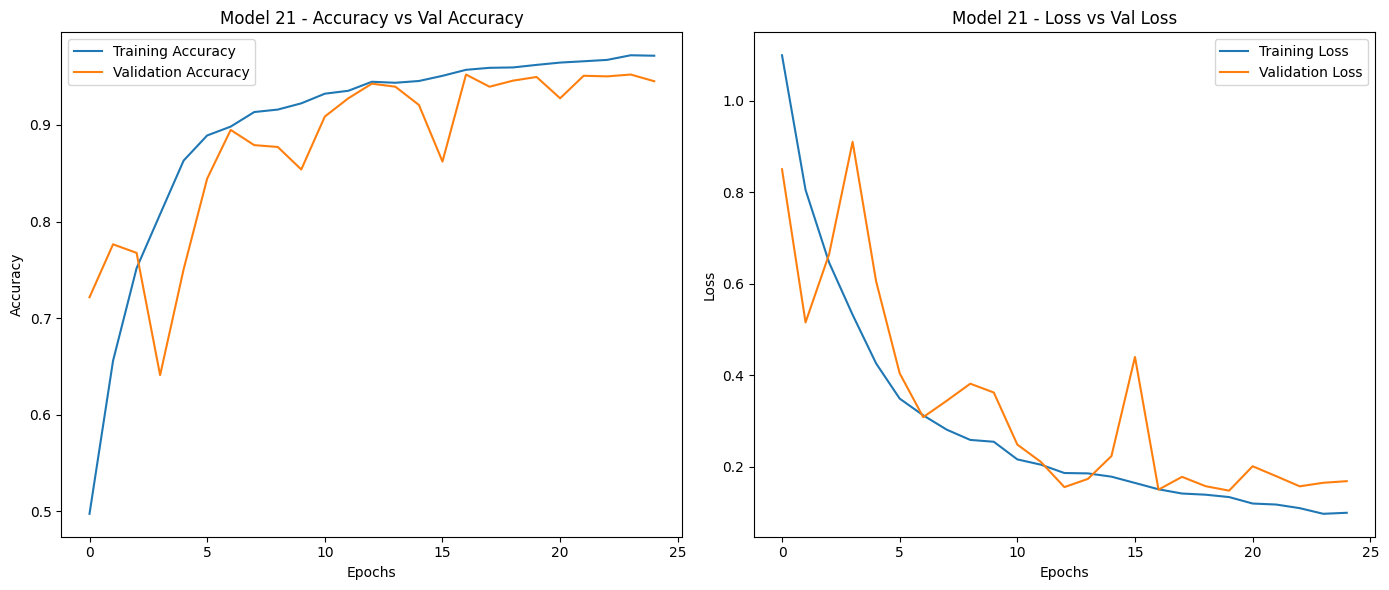


Model 21 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 22/30

Model 22 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.004790427026927698
  weight_decay: 0.007558766397863605
  batch_size: 32

=== Evaluating Model 22 ===

[== Evaluation on Test - Model 22 Data ==]
Test - Model 22 Loss: 0.1452
Test - Model 22 Accuracy: 0.9623

Classification Report (Test - Model 22 Data):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       112
           1       0.95      0.91      0.93       115
           2       0.98      0.99      0.99       189
           3       0.97      0.96      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96  

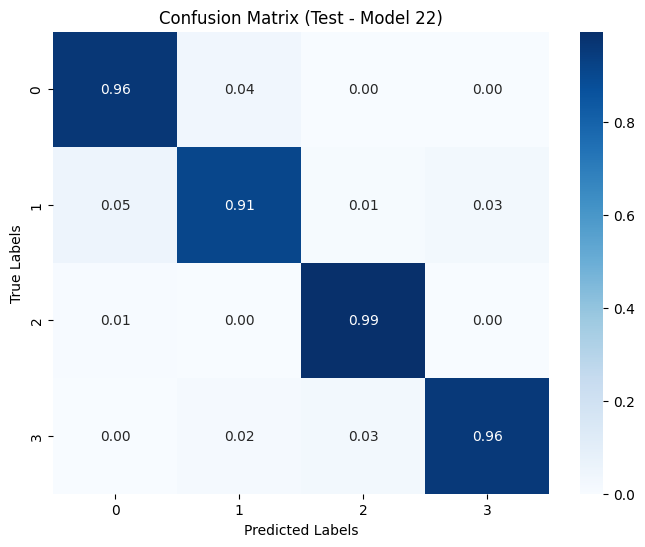


[== Evaluation on External - Model 22 Data ==]
External - Model 22 Loss: 1.1522
External - Model 22 Accuracy: 0.7830

Classification Report (External - Model 22 Data):
              precision    recall  f1-score   support

           0       0.68      0.77      0.72      1008
           1       0.29      0.96      0.44       229
           2       0.24      0.99      0.39       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.55      0.87      0.61     10834
weighted avg       0.92      0.78      0.83     10834

External - Model 22 AUC: 0.9567


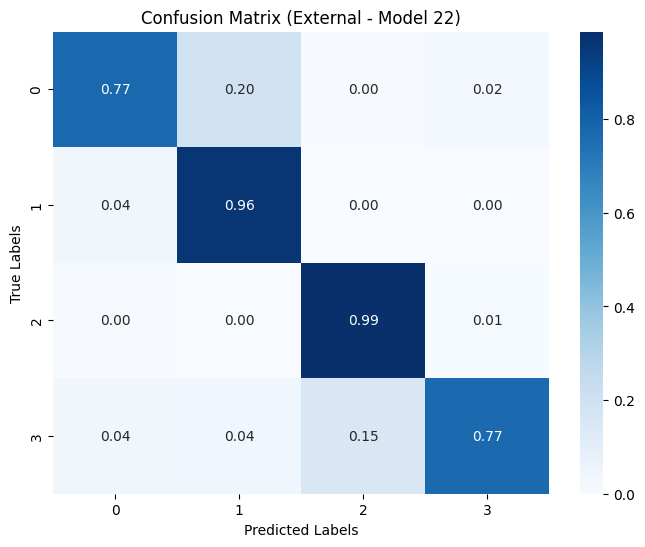

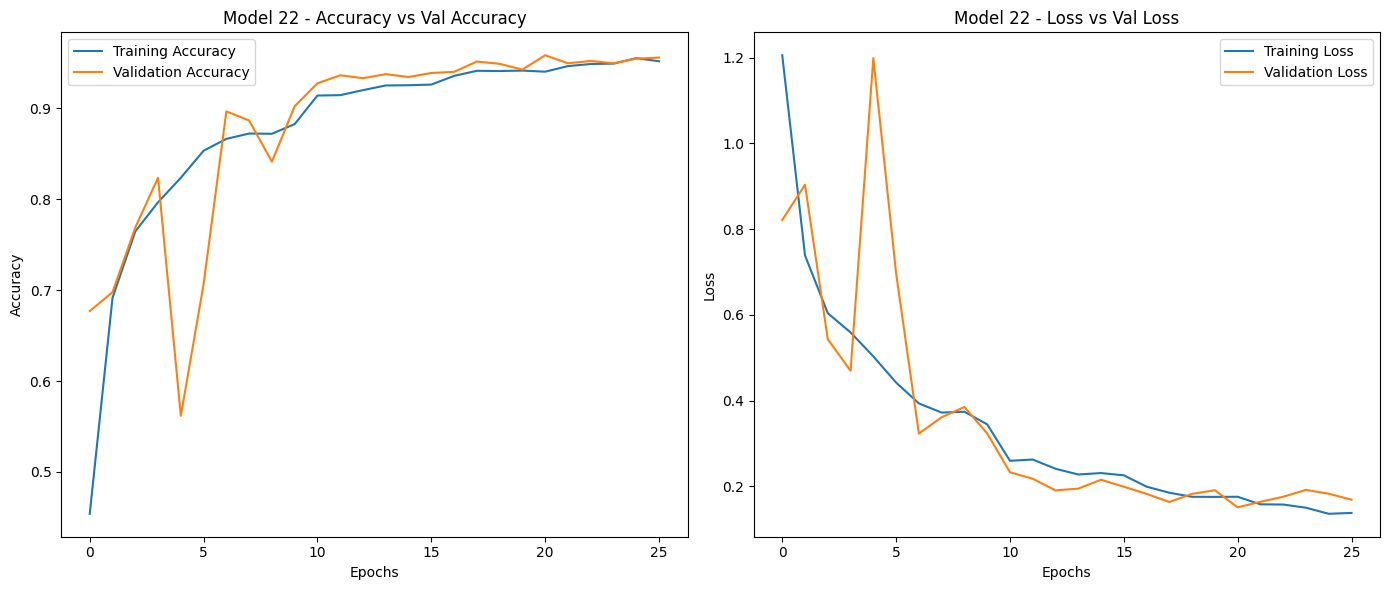


Model 22 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 23/30

Model 23 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.4
  learning_rate: 0.003433199291594156
  weight_decay: 0.00700813123038703
  batch_size: 32

=== Evaluating Model 23 ===

[== Evaluation on Test - Model 23 Data ==]
Test - Model 23 Loss: 0.1563
Test - Model 23 Accuracy: 0.9547

Classification Report (Test - Model 23 Data):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       112
           1       0.91      0.93      0.92       115
           2       0.97      1.00      0.98       189
           3       0.98      0.93      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.95      0.95    

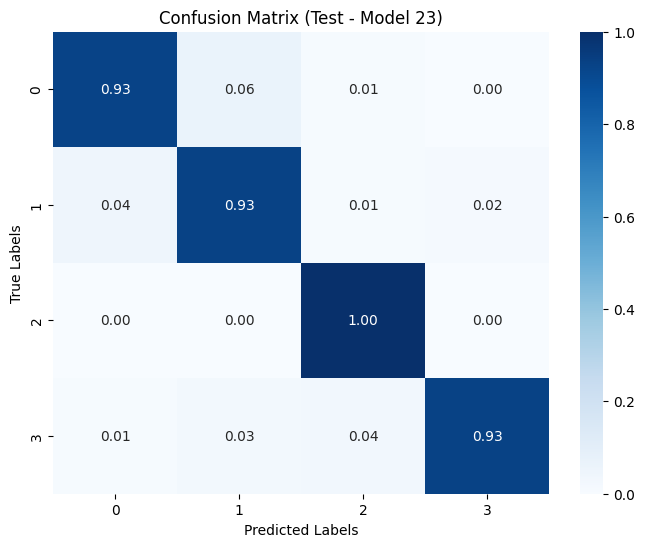


[== Evaluation on External - Model 23 Data ==]
External - Model 23 Loss: 1.0743
External - Model 23 Accuracy: 0.7807

Classification Report (External - Model 23 Data):
              precision    recall  f1-score   support

           0       0.67      0.77      0.71      1008
           1       0.24      1.00      0.39       229
           2       0.26      0.98      0.41       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.54      0.88      0.60     10834
weighted avg       0.92      0.78      0.82     10834

External - Model 23 AUC: 0.9652


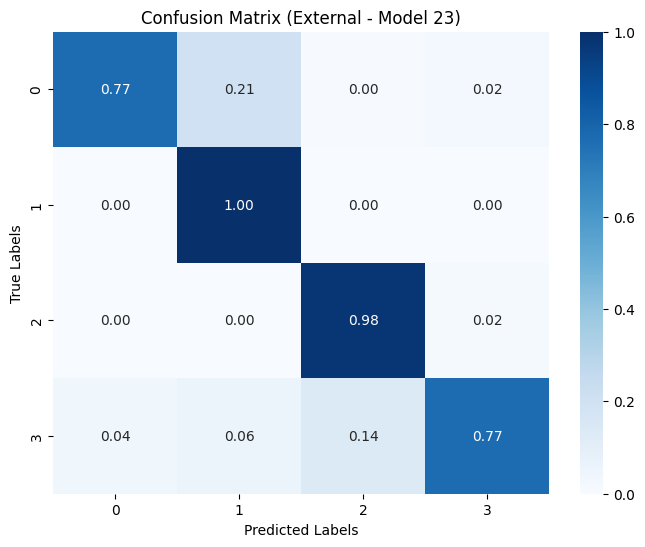

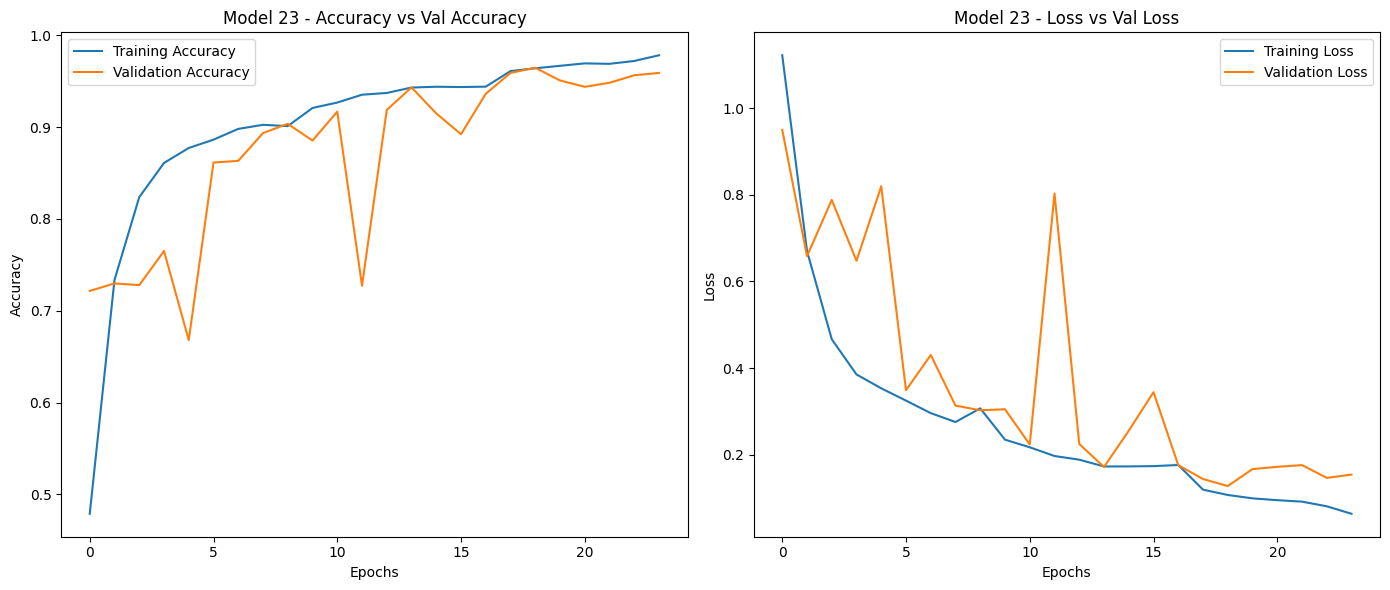


Model 23 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 24/30

Model 24 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.3
  learning_rate: 0.0035627178632530185
  weight_decay: 0.007573032432866472
  batch_size: 32

=== Evaluating Model 24 ===

[== Evaluation on Test - Model 24 Data ==]
Test - Model 24 Loss: 0.1647
Test - Model 24 Accuracy: 0.9566

Classification Report (Test - Model 24 Data):
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       112
           1       0.92      0.94      0.93       115
           2       0.96      0.99      0.98       189
           3       0.99      0.92      0.95       114

    accuracy                           0.96       530
   macro avg       0.96      0.95      0.95       530
weighted avg       0.96      0.96   

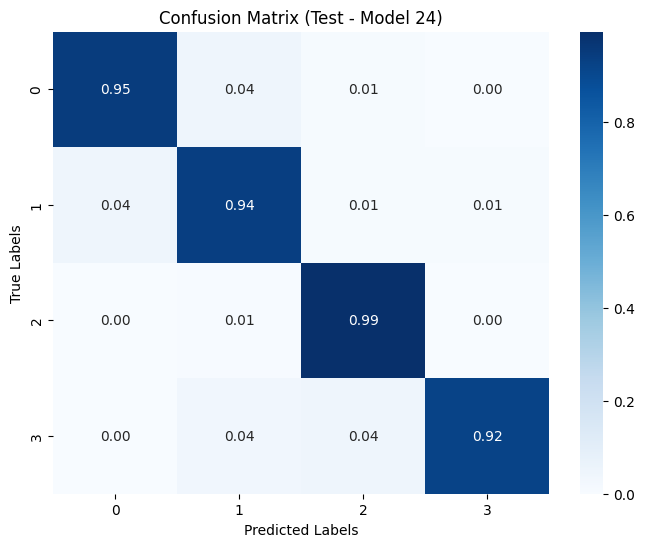


[== Evaluation on External - Model 24 Data ==]
External - Model 24 Loss: 1.0333
External - Model 24 Accuracy: 0.7759

Classification Report (External - Model 24 Data):
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      1008
           1       0.26      0.95      0.40       229
           2       0.23      0.99      0.37       456
           3       1.00      0.76      0.86      9141

    accuracy                           0.78     10834
   macro avg       0.56      0.87      0.60     10834
weighted avg       0.93      0.78      0.82     10834

External - Model 24 AUC: 0.9574


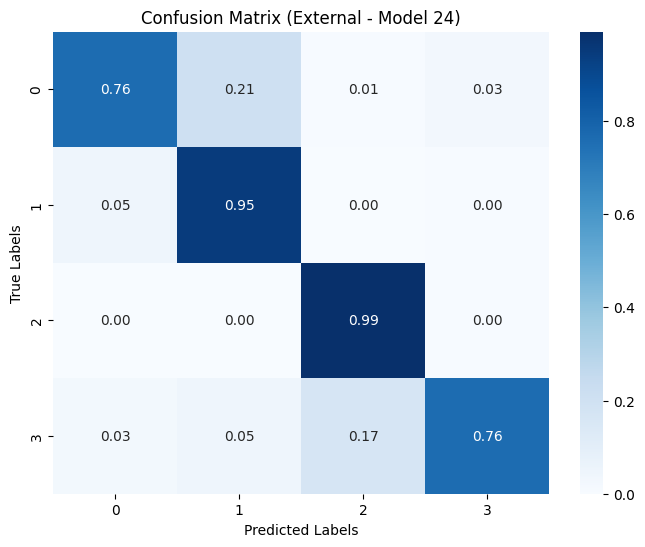

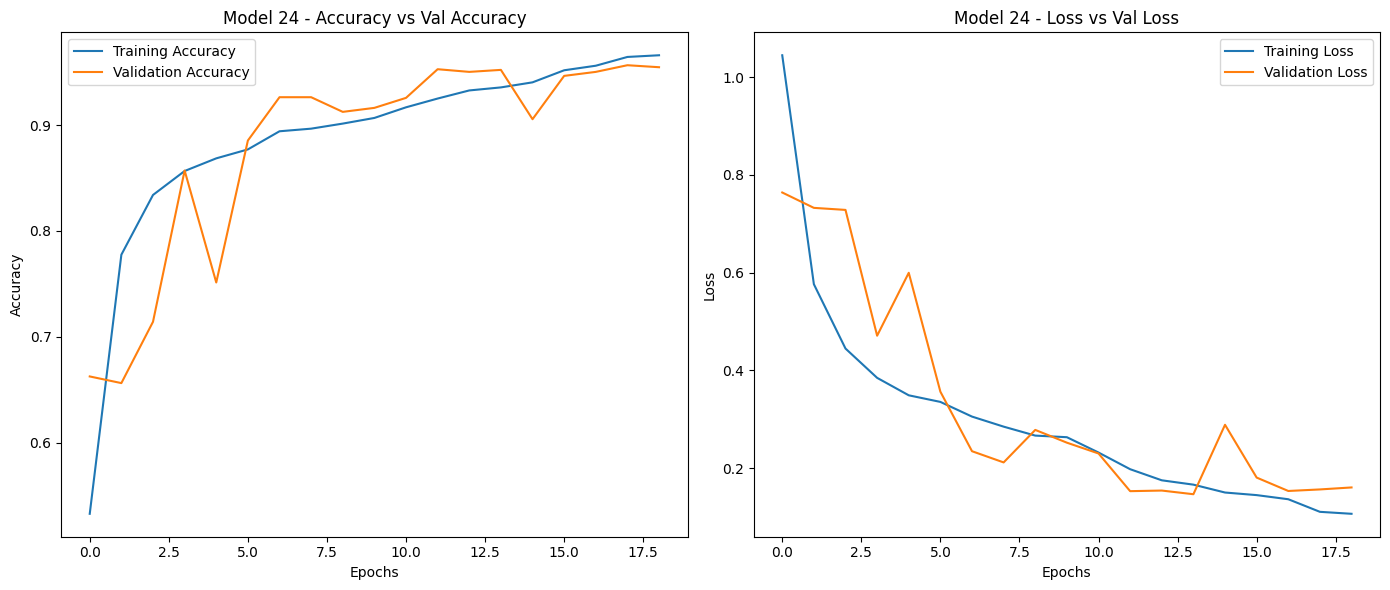


Model 24 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 25/30

Model 25 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.004811158879738167
  weight_decay: 0.004463839868341395
  batch_size: 32

=== Evaluating Model 25 ===

[== Evaluation on Test - Model 25 Data ==]
Test - Model 25 Loss: 0.1548
Test - Model 25 Accuracy: 0.9491

Classification Report (Test - Model 25 Data):
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       112
           1       0.94      0.90      0.92       115
           2       0.96      0.99      0.98       189
           3       0.97      0.92      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.94      0.94       530
weighted avg       0.95      0.95  

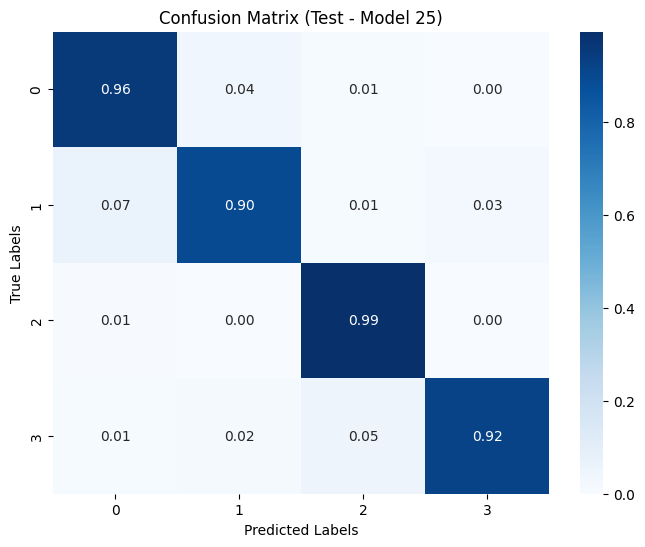


[== Evaluation on External - Model 25 Data ==]
External - Model 25 Loss: 1.1249
External - Model 25 Accuracy: 0.7879

Classification Report (External - Model 25 Data):
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      1008
           1       0.25      0.99      0.40       229
           2       0.24      0.98      0.39       456
           3       0.99      0.78      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.57      0.87      0.61     10834
weighted avg       0.93      0.79      0.83     10834

External - Model 25 AUC: 0.9640


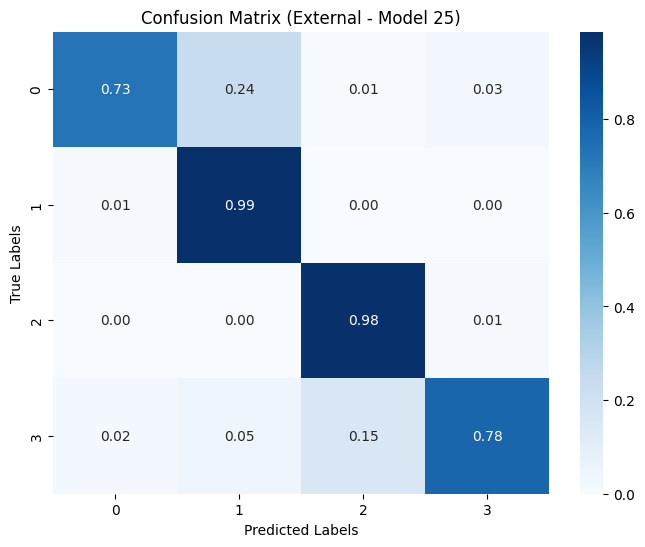

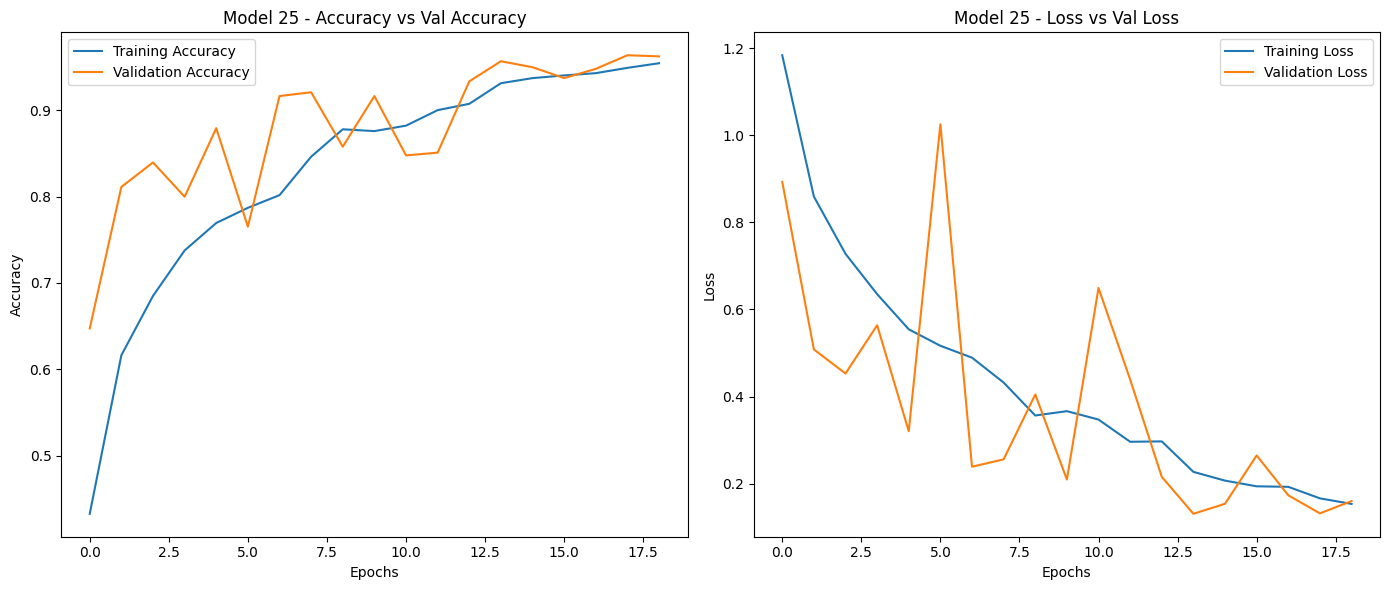


Model 25 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 26/30

Model 26 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.004970061670115483
  weight_decay: 0.00580121868874685
  batch_size: 32

=== Evaluating Model 26 ===

[== Evaluation on Test - Model 26 Data ==]
Test - Model 26 Loss: 0.2116
Test - Model 26 Accuracy: 0.9566

Classification Report (Test - Model 26 Data):
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       112
           1       0.90      0.96      0.93       115
           2       0.98      0.98      0.98       189
           3       0.98      0.93      0.95       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96   

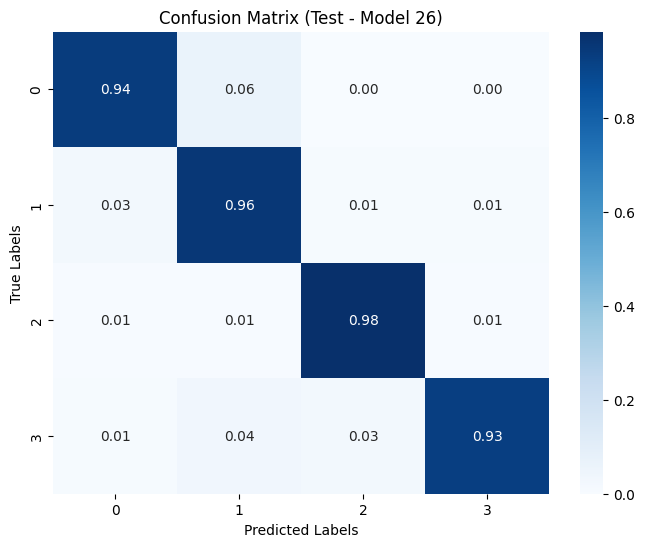


[== Evaluation on External - Model 26 Data ==]
External - Model 26 Loss: 1.2533
External - Model 26 Accuracy: 0.7896

Classification Report (External - Model 26 Data):
              precision    recall  f1-score   support

           0       0.82      0.74      0.78      1008
           1       0.24      0.99      0.39       229
           2       0.25      0.99      0.40       456
           3       1.00      0.78      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.58      0.87      0.61     10834
weighted avg       0.93      0.79      0.84     10834

External - Model 26 AUC: 0.9532


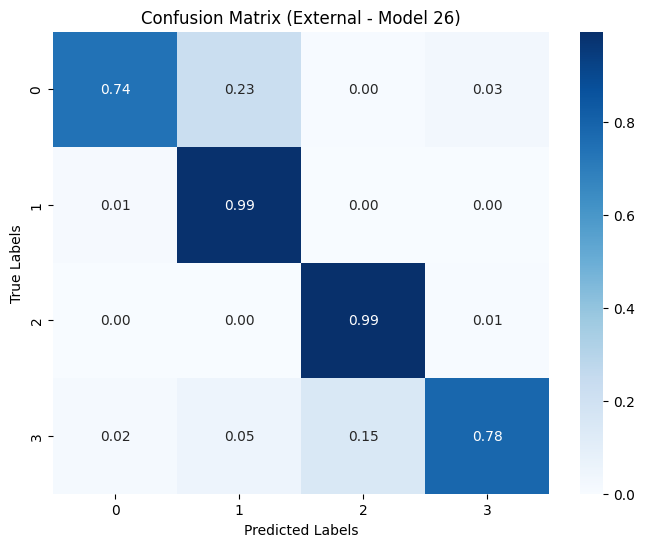

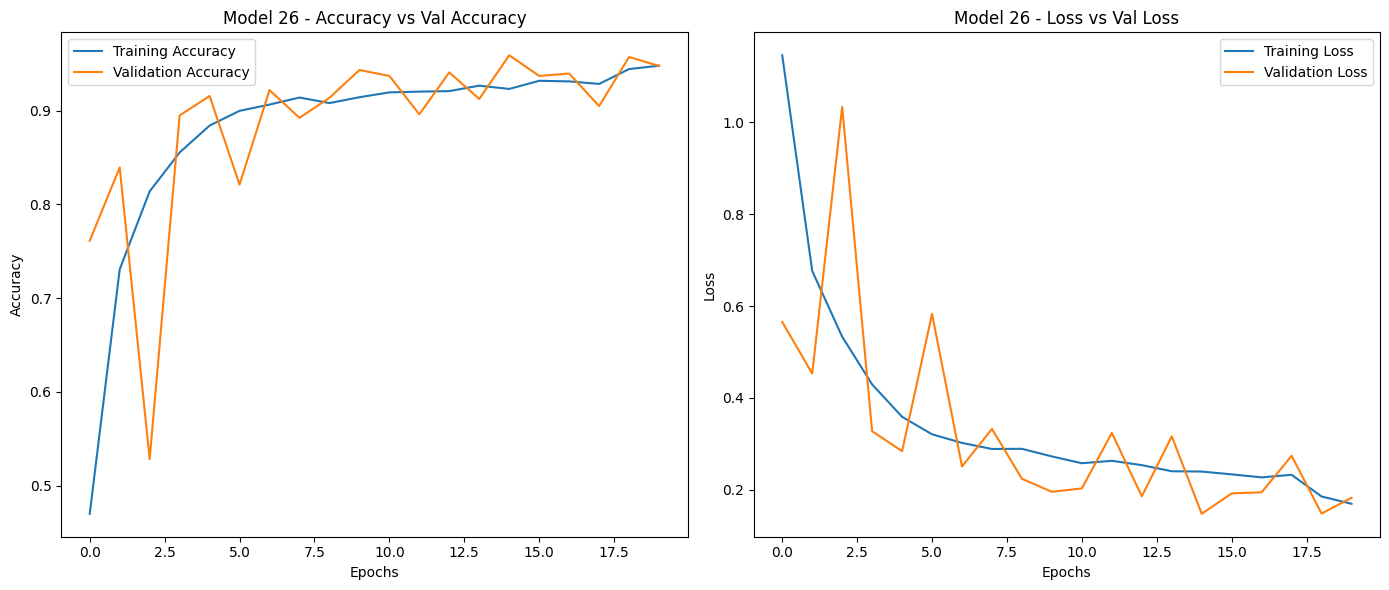


Model 26 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 27/30

Model 27 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.4
  dense_units_2: 64
  dropout_2: 0.45
  learning_rate: 0.0031865592861908647
  weight_decay: 0.01
  batch_size: 32

=== Evaluating Model 27 ===

[== Evaluation on Test - Model 27 Data ==]
Test - Model 27 Loss: 0.1413
Test - Model 27 Accuracy: 0.9623

Classification Report (Test - Model 27 Data):
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       112
           1       0.95      0.92      0.93       115
           2       0.98      0.99      0.98       189
           3       0.98      0.96      0.97       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96      0.96       5

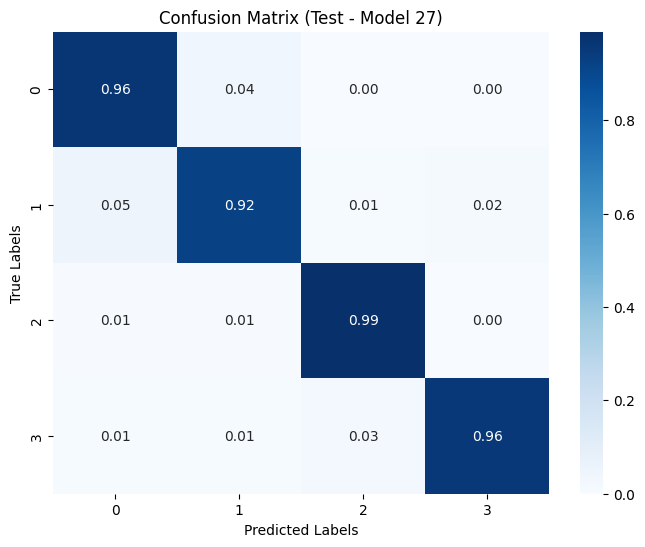


[== Evaluation on External - Model 27 Data ==]
External - Model 27 Loss: 0.9610
External - Model 27 Accuracy: 0.8069

Classification Report (External - Model 27 Data):
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1008
           1       0.32      0.96      0.48       229
           2       0.25      0.98      0.40       456
           3       0.99      0.79      0.88      9141

    accuracy                           0.81     10834
   macro avg       0.58      0.88      0.64     10834
weighted avg       0.93      0.81      0.85     10834

External - Model 27 AUC: 0.9651


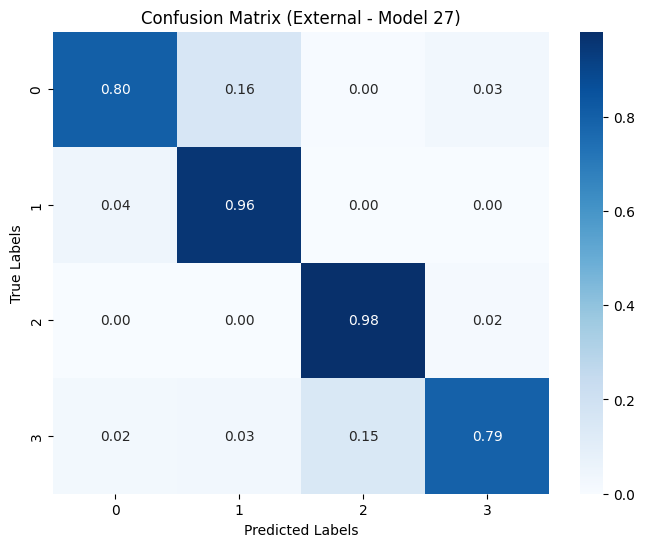

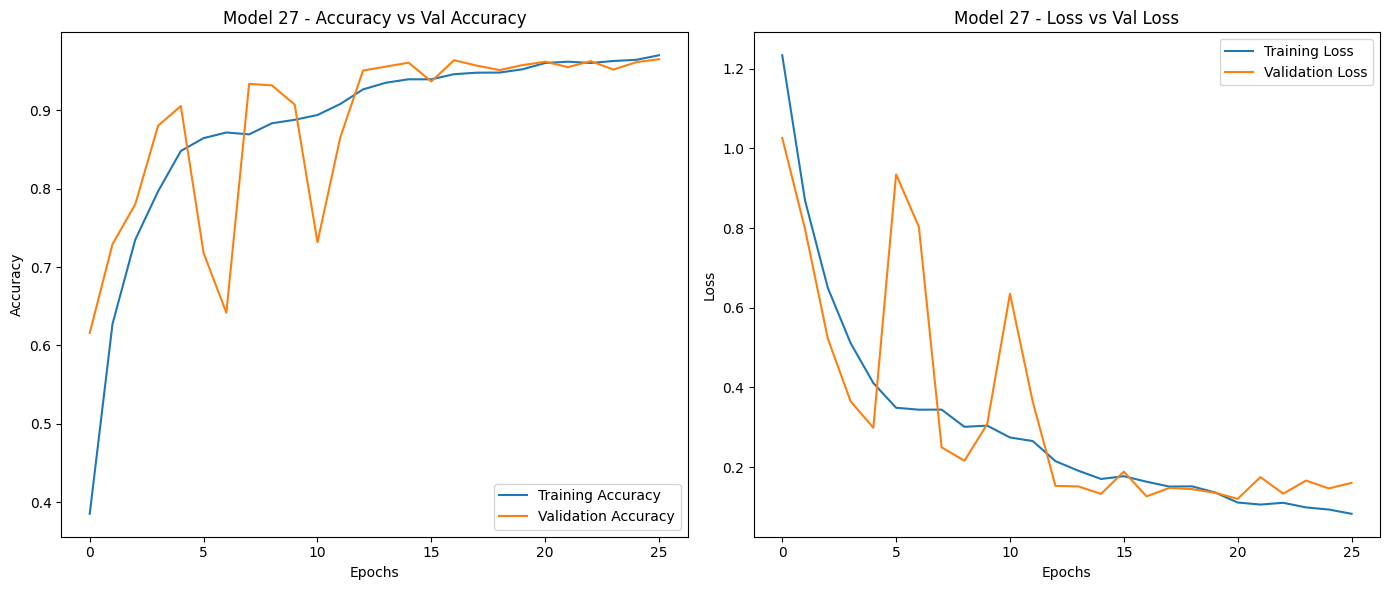


Model 27 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 28/30

Model 28 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.35
  dense_units_2: 64
  dropout_2: 0.4
  learning_rate: 0.0029687908708412106
  weight_decay: 0.008281663427970399
  batch_size: 32

=== Evaluating Model 28 ===

[== Evaluation on Test - Model 28 Data ==]
Test - Model 28 Loss: 0.1507
Test - Model 28 Accuracy: 0.9566

Classification Report (Test - Model 28 Data):
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       112
           1       0.95      0.89      0.92       115
           2       0.98      1.00      0.99       189
           3       0.98      0.93      0.95       114

    accuracy                           0.96       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.96  

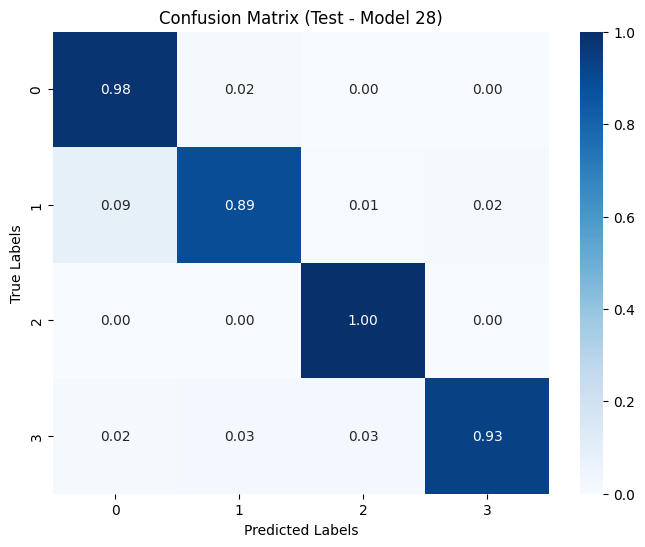


[== Evaluation on External - Model 28 Data ==]
External - Model 28 Loss: 1.0827
External - Model 28 Accuracy: 0.7893

Classification Report (External - Model 28 Data):
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      1008
           1       0.28      0.97      0.44       229
           2       0.24      1.00      0.38       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.79     10834
   macro avg       0.57      0.89      0.62     10834
weighted avg       0.93      0.79      0.83     10834

External - Model 28 AUC: 0.9631


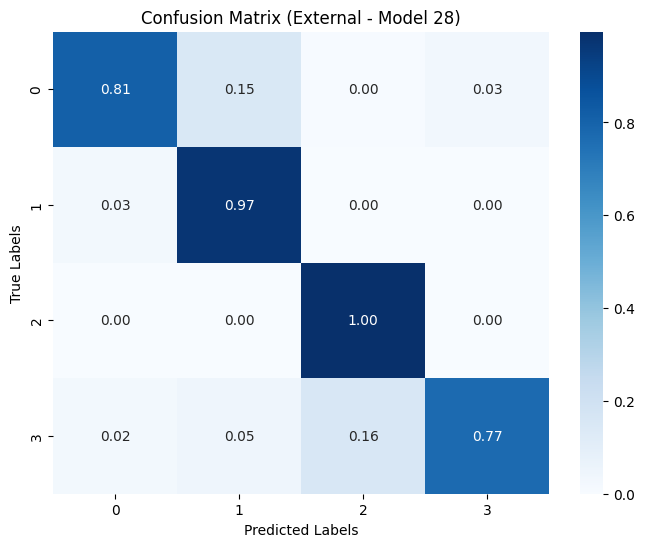

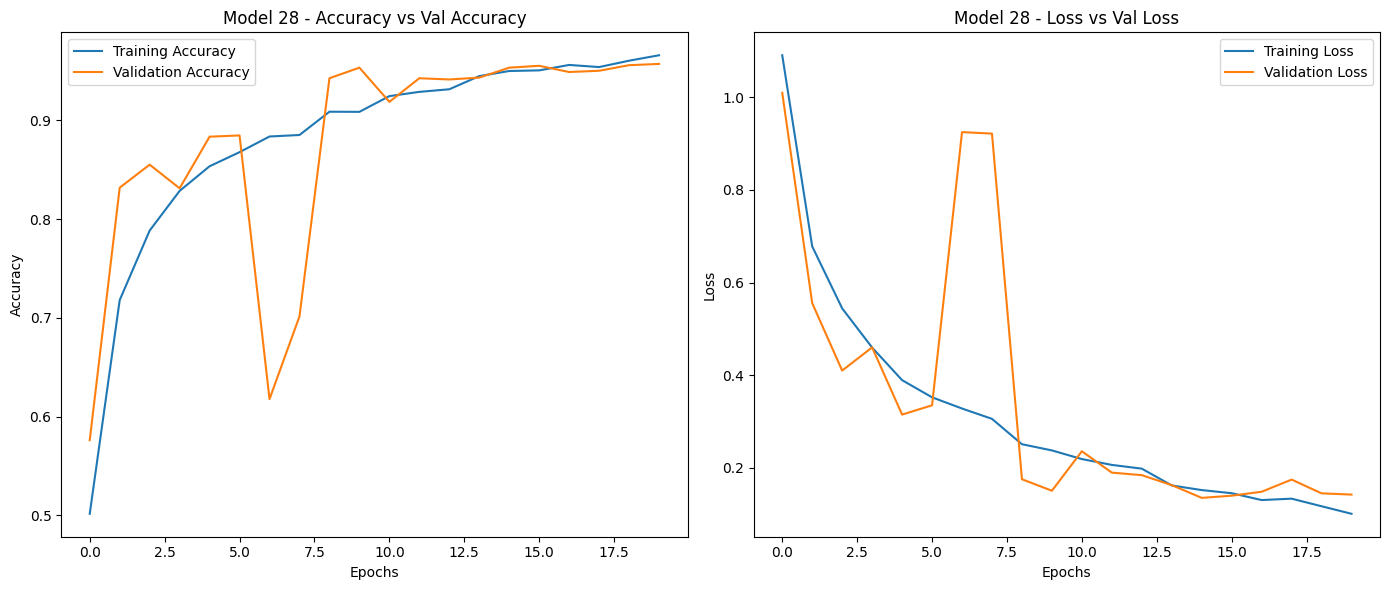


Model 28 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 29/30

Model 29 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.3
  dense_units_2: 32
  dropout_2: 0.35
  learning_rate: 0.003460357366748836
  weight_decay: 0.003421771758553947
  batch_size: 32

=== Evaluating Model 29 ===

[== Evaluation on Test - Model 29 Data ==]
Test - Model 29 Loss: 0.1631
Test - Model 29 Accuracy: 0.9547

Classification Report (Test - Model 29 Data):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       112
           1       0.94      0.91      0.93       115
           2       0.97      0.99      0.98       189
           3       0.98      0.93      0.95       114

    accuracy                           0.95       530
   macro avg       0.95      0.95      0.95       530
weighted avg       0.96      0.95   

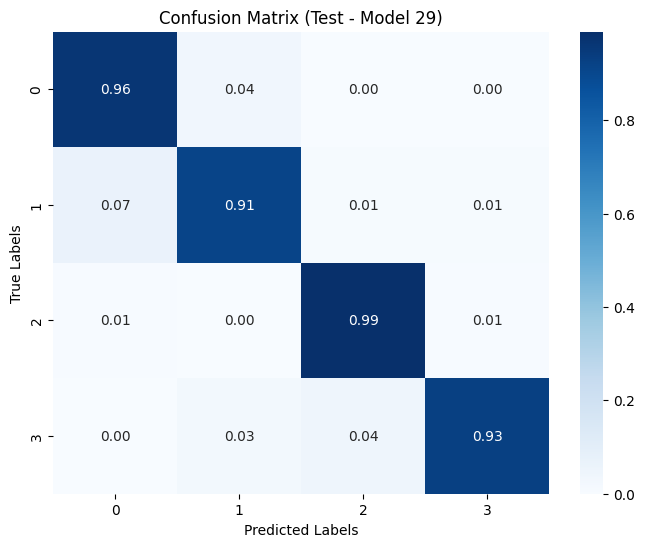


[== Evaluation on External - Model 29 Data ==]
External - Model 29 Loss: 1.3492
External - Model 29 Accuracy: 0.7622

Classification Report (External - Model 29 Data):
              precision    recall  f1-score   support

           0       0.54      0.72      0.62      1008
           1       0.26      0.98      0.41       229
           2       0.26      0.98      0.41       456
           3       1.00      0.75      0.86      9141

    accuracy                           0.76     10834
   macro avg       0.51      0.86      0.57     10834
weighted avg       0.91      0.76      0.81     10834

External - Model 29 AUC: 0.9496


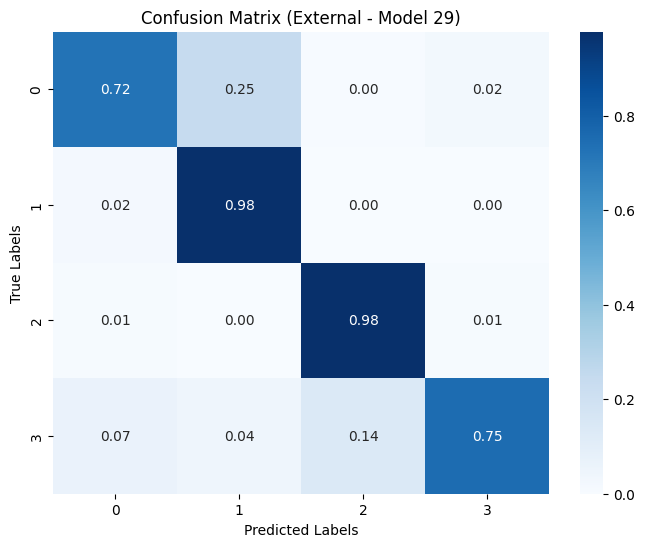

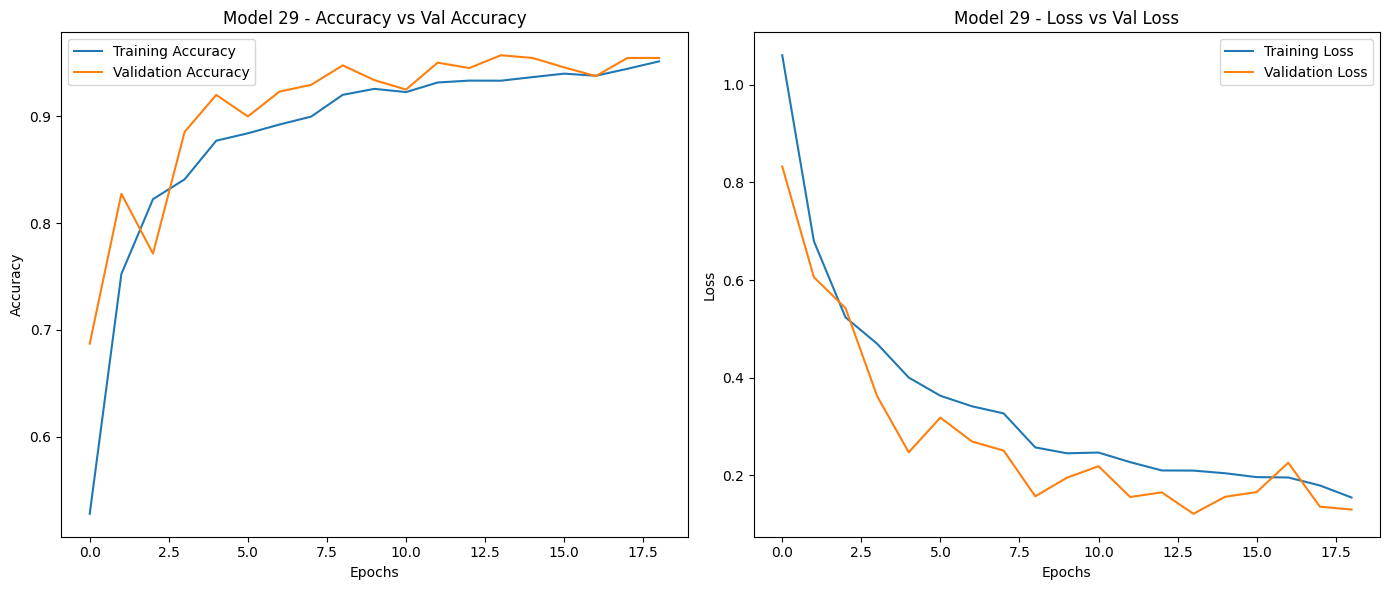


Model 29 evaluation and plotting completed!

EVALUATING AND PLOTTING MODEL 30/30

Model 30 Hyperparameters:
  f_units: 32
  p_size: 5
  n_convolutions: 3
  m_convolutions: 3
  kernel_size_init: 3
  kernel_size_res: 3
  coefficient: 1
  dense_units_1: 64
  dropout_1: 0.4
  dense_units_2: 64
  dropout_2: 0.35
  learning_rate: 0.005170615975493908
  weight_decay: 0.006825526824363153
  batch_size: 32

=== Evaluating Model 30 ===

[== Evaluation on Test - Model 30 Data ==]
Test - Model 30 Loss: 0.1208
Test - Model 30 Accuracy: 0.9642

Classification Report (Test - Model 30 Data):
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       112
           1       0.95      0.92      0.94       115
           2       0.98      0.99      0.99       189
           3       0.97      0.95      0.96       114

    accuracy                           0.96       530
   macro avg       0.96      0.96      0.96       530
weighted avg       0.96      0.96   

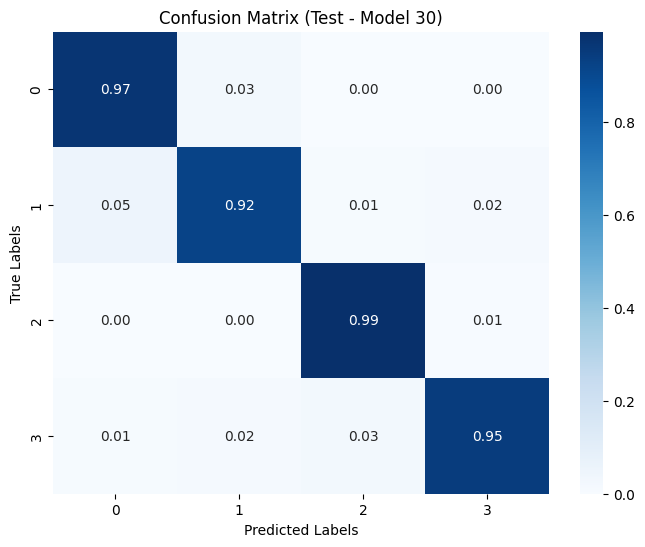


[== Evaluation on External - Model 30 Data ==]
External - Model 30 Loss: 0.8854
External - Model 30 Accuracy: 0.7823

Classification Report (External - Model 30 Data):
              precision    recall  f1-score   support

           0       0.64      0.76      0.70      1008
           1       0.26      0.96      0.41       229
           2       0.26      0.98      0.41       456
           3       1.00      0.77      0.87      9141

    accuracy                           0.78     10834
   macro avg       0.54      0.87      0.60     10834
weighted avg       0.92      0.78      0.82     10834

External - Model 30 AUC: 0.9601


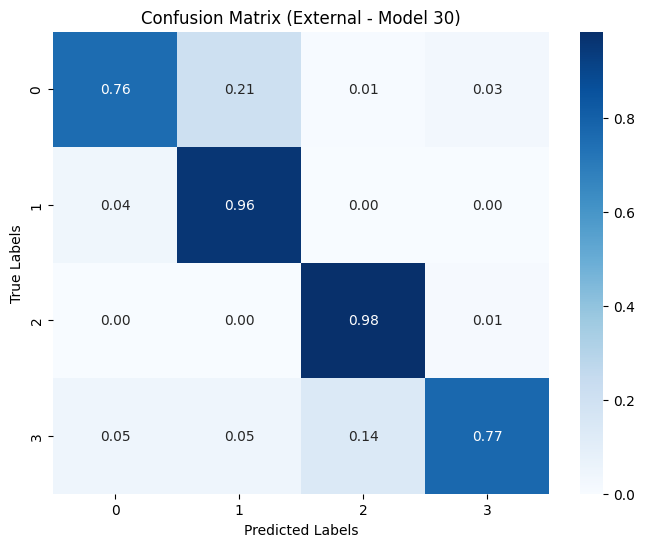

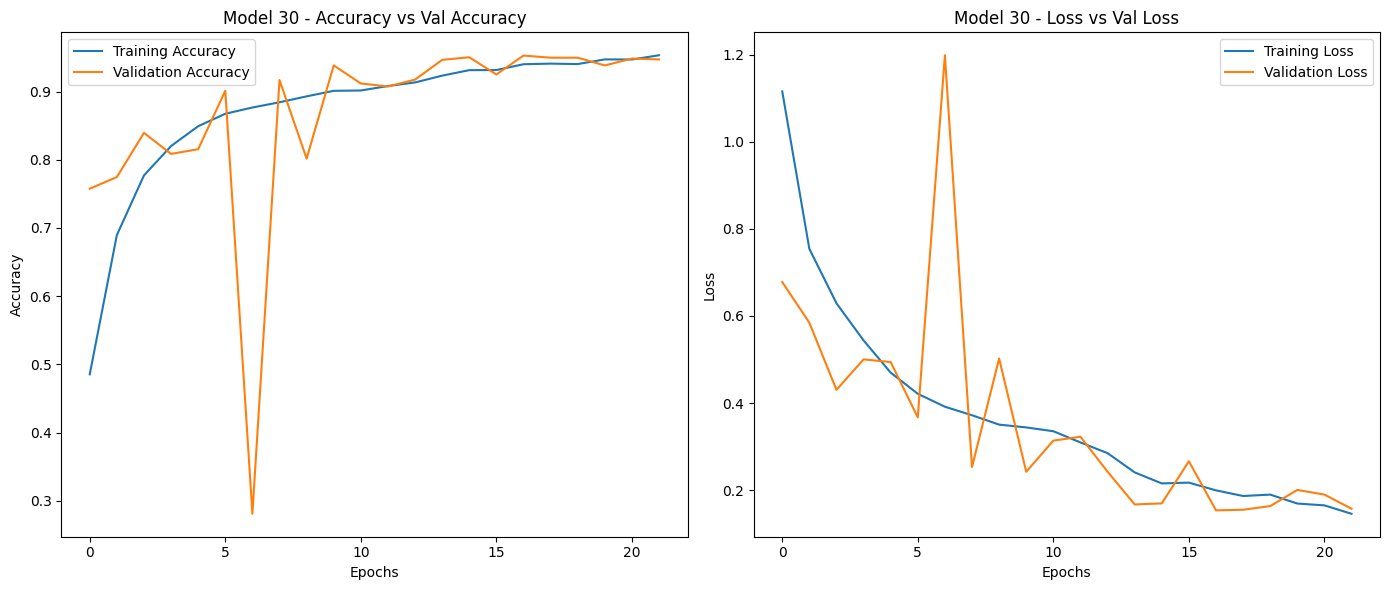


Model 30 evaluation and plotting completed!

PHASE 2 COMPLETED: 30 MODELS EVALUATED AND PLOTTED


In [4]:
import pickle
results_dir = c.RDIR / f"RES_{c.INPUT_SIZE}_{c.FILTERS}"
results_dir.mkdir(parents=True, exist_ok=True)

all_model_results = []
print("Loading individual model results...")

for model_idx in range(c.NUM_MODELS):
    individual_model_file = results_dir / f"model_{model_idx + 1}.pkl"
    
    if individual_model_file.exists():
        with open(individual_model_file, "rb") as f:
            model_result = pickle.load(f)
            all_model_results.append(model_result)
            print(f"✅ Loaded Model {model_idx + 1} results from {individual_model_file}")
    else:
        print(f"❌ Model {model_idx + 1} results not found at {individual_model_file}")

print(f"Total models loaded: {len(all_model_results)}")


dataset_loader_external = ds_loader.DatasetLoader(xlsx_path="../Data/External_Dataset/Label_Map.xlsx",data_dir="../Data/External_Dataset")
X_test_external, y_test_external = dataset_loader_external.load_data()
X_test_external, X_test = min_max_normalize(X_test_external, X_test)
print(f"External dataset loaded: {X_test_external.shape[0]} samples")

def evaluate_model(model, X, y, label="Test"):
    print(f"\n[== Evaluation on {label} Data ==]")

    loss, accuracy = model.evaluate(X, y, batch_size=32, verbose=0)
    print(f"{label} Loss: {loss:.4f}")
    print(f"{label} Accuracy: {accuracy:.4f}")

    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nClassification Report ({label} Data):")
    print(sklearn.metrics.classification_report(y, y_pred))

    try:
        auc = sklearn.metrics.roc_auc_score(y, y_pred_probs, multi_class='ovr')
        print(f"{label} AUC: {auc:.4f}")
    except Exception as e:
        print(f"AUC could not be calculated: {e}")

    plot_confusion_matrix(y, y_pred, label)
    
    return accuracy, loss

def plot_confusion_matrix(y_true, y_pred, label="Test"):
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix ({label})')
    plt.show()

# Loop through all models for evaluation and plotting
for model_idx in range(c.NUM_MODELS):
    print(f"\n{'='*60}")
    print(f"EVALUATING AND PLOTTING MODEL {model_idx + 1}/{c.NUM_MODELS}")
    print(f"{'='*60}")
    
    cv_model = tf.keras.models.load_model(f"{c.CVDIR}_model_{model_idx + 1}.keras")
    
    model_result = all_model_results[model_idx]
    
    print(f"\nModel {model_idx + 1} Hyperparameters:")
    for param_name, param_value in model_result['hyperparameters'].items():
        print(f"  {param_name}: {param_value}")

    
    print(f"\n=== Evaluating Model {model_idx + 1} ===")
    test_acc, test_loss = evaluate_model(cv_model, X_test, y_test, f"Test - Model {model_idx + 1}")
    external_acc, external_loss = evaluate_model(cv_model, X_test_external, y_test_external, f"External - Model {model_idx + 1}")
    
    model_result.update({
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'external_accuracy': external_acc,
        'external_loss': external_loss
    })
     
    
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    ax[0].plot(model_result['history'].history['accuracy'], label='Training Accuracy')
    ax[0].plot(model_result['history'].history['val_accuracy'], label='Validation Accuracy')
    ax[0].set_title(f'Model {model_idx + 1} - Accuracy vs Val Accuracy')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()

    ax[1].plot(model_result['history'].history['loss'], label='Training Loss')
    ax[1].plot(model_result['history'].history['val_loss'], label='Validation Loss')
    ax[1].set_title(f'Model {model_idx + 1} - Loss vs Val Loss')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Loss')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    
    print(f"\nModel {model_idx + 1} evaluation and plotting completed!")

print(f"\n{'='*80}")
print(f"PHASE 2 COMPLETED: {c.NUM_MODELS} MODELS EVALUATED AND PLOTTED")
print(f"{'='*80}")